# Rainfall Variability, ENSO, and Extreme Wet Conditions in Vietnam

## Introduction

This project investigates rainfall variability across Vietnam, with a particular focus on unusually wet conditions in 2025 and selected regional case studies.

The analysis first examines how precipitation in 2025 differed from historical climate conditions across Vietnam. It then evaluates the historical relationship between ENSO and rainfall variability using the Niño 3.4 index and the Standardized Precipitation Index (SPI).

The analysis further assesses whether the rainfall anomalies observed in 2025 were consistent with the historical ENSO–rainfall relationship. Two case studies are examined in greater detail: unusually wet conditions in Khanh Hoa in November 2025 and rainfall variability in Ho Chi Minh City during 2026.

ERA5-Land monthly precipitation data from 1950 to August 2026 are combined with NOAA sea surface temperature data to construct a standardized Niño 3.4 ENSO index.

## Installing Python packages (only for Google Colab)

Run this cell when starting a new Google Colab environment.

In [1]:
!pip install -q cartopy netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.7 MB/s eta 0:00:00


## 1: Importing Python packages

Python packages are imported for handling multidimensional climate data, statistical analysis, and spatial visualization.

In [68]:
# Import working modules
import xarray as xr
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import os
import warnings
import statsmodels.api as sm

from pathlib import Path
from shapely import contains_xy

warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline

In [3]:
# Mount Google Drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


Make sure that the working folder path is correct.

In [4]:
# Define paths
my_drive = Path("/content/drive/MyDrive/")
workingfolder = my_drive / "Rainfall project"

inputfolder = workingfolder / "Data"
figurefolder = workingfolder / "Figures"
outputfolder = workingfolder / "Output"

era5_file = inputfolder / "ERA5_Land" / "data_stream-moda.nc"

## 2: Loading and inspecting precipitation data

We first load the ERA5-Land monthly precipitation dataset and inspect its multidimensional structure.

### 2a: Inspecting the data with the xarray package

The precipitation data are stored as an xarray DataArray with time, latitude, and longitude dimensions. ERA5-Land total precipitation is provided in metres.

In [5]:
# Load precipitation data
precip_m = xr.open_dataset(era5_file)["tp"]

print("Variable:", precip_m.name)
print("Dimensions:", dict(precip_m.sizes))
print(
    "Period:",
    str(precip_m.valid_time.values[0])[:10],
    "to",
    str(precip_m.valid_time.values[-1])[:10]
)
print("Original units:", precip_m.attrs.get("units"))

Variable: tp
Dimensions: {'valid_time': 920, 'latitude': 451, 'longitude': 551}
Period: 1950-01-01 to 2026-08-01
Original units: m


### 2b: Converting precipitation to monthly totals

ERA5-Land monthly total precipitation is stored in metres. For the monthly averaged product, the values represent mean daily precipitation over each month. Therefore, precipitation is converted to monthly totals in millimetres by multiplying by 1,000 and by the number of days in each month.

In [6]:
# Convert precipitation from m/day to mm/month
days_in_month = precip_m["valid_time"].dt.days_in_month

precip = precip_m * 1000 * days_in_month

precip.name = "Precipitation"
precip.attrs["units"] = "mm/month"

print("Converted units:", precip.attrs["units"])
print("Mean precipitation:", round(float(precip.mean()), 2), "mm/month")

Converted units: mm/month
Mean precipitation: 194.14 mm/month


In [7]:
# Check precipitation values
print("Minimum:", float(precip.min()))
print("Maximum:", float(precip.max()))
print("Mean:", float(precip.mean()))

Minimum: 0.009672837622929364
Maximum: 5053.452209472656
Mean: 194.14254825638588


## 3: Climatological precipitation

### 3a: Spatial annual precipitation climatology over Southeast Asia

The long-term mean annual precipitation is calculated to examine the broad spatial distribution of rainfall across Southeast Asia.

In [8]:
# Calculate annual precipitation totals
annual_precip_clim = precip.groupby("valid_time.year").sum(
    dim="valid_time",
    skipna=True,
    min_count=1
)

# Calculate long-term mean annual precipitation
precip_clim = annual_precip_clim.mean(dim="year")

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


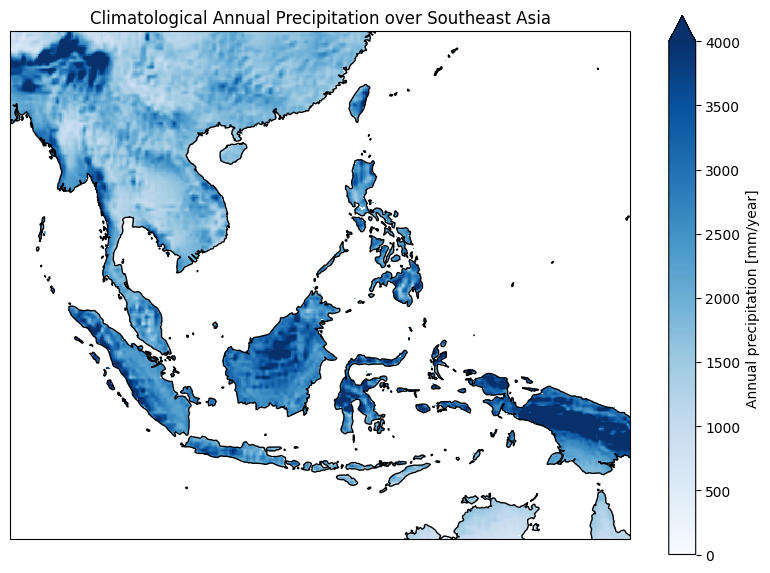

In [9]:
# Plot annual precipitation climatology over Southeast Asia
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

precip_clim.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.Blues,
    vmin=0,
    vmax=4000,
    cbar_kwargs={"label": "Annual precipitation [mm/year]"}
)

ax.coastlines()
ax.set_extent([90, 145, -15, 30], crs=ccrs.PlateCarree())

plt.title("Climatological Annual Precipitation over Southeast Asia")
plt.show()

### 3b: Retrieve precipitation data for Vietnam

A country boundary from Natural Earth is used to extract precipitation data for Vietnam.

In [10]:
# Load country boundaries
shpfilename = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

reader = shpreader.Reader(shpfilename)

vietnam_geometry = None

for record in reader.records():
    if record.attributes["ADMIN"] == "Vietnam":
        vietnam_geometry = record.geometry
        break

print("Vietnam boundary found:", vietnam_geometry is not None)

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Vietnam boundary found: True


In [11]:
# Create Vietnam mask
lon2d, lat2d = np.meshgrid(
    precip.longitude.values,
    precip.latitude.values
)

Vietnam_mask = contains_xy(
    vietnam_geometry,
    lon2d,
    lat2d
)

Vietnam_mask = xr.DataArray(
    Vietnam_mask,
    coords={
        "latitude": precip.latitude,
        "longitude": precip.longitude
    },
    dims=("latitude", "longitude")
)

pr_vietnam = precip.where(Vietnam_mask)

print("Vietnam grid cells:", int(Vietnam_mask.sum()))

Vietnam grid cells: 2858


In [12]:
# Calculate annual precipitation totals over Vietnam
vietnam_annual = pr_vietnam.groupby("valid_time.year").sum(
    dim="valid_time",
    skipna=True,
    min_count=1
)

# Calculate long-term mean annual precipitation
vietnam_clim = vietnam_annual.mean(dim="year")

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


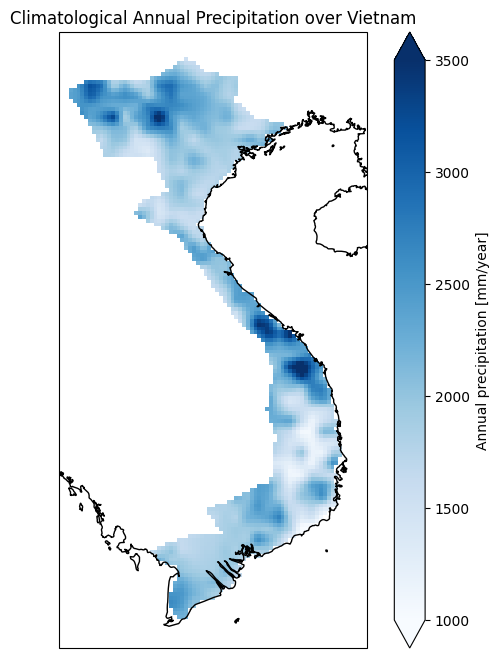

In [13]:
# Plot annual precipitation climatology over Vietnam
fig = plt.figure(figsize=(7, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

vietnam_clim.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.Blues,
    vmin=1000,
    vmax=3500,
    cbar_kwargs={"label": "Annual precipitation [mm/year]"}
)

ax.coastlines()
ax.set_extent([102, 110, 8, 24], crs=ccrs.PlateCarree())

plt.title("Climatological Annual Precipitation over Vietnam")
plt.show()

## 4: Comparing rainfall in 2024 and 2025

Rainfall conditions in 2024 and 2025 are compared across Vietnam to examine both the overall annual differences and their temporal evolution throughout the year.

The analysis first compares annual precipitation anomalies across six regions, and then examines monthly rainfall patterns to identify when the strongest differences between the two years occurred.

### 4a: Regional annual rainfall anomalies

In [14]:
# Select precipitation in 2024 and 2025
precip_2024 = pr_vietnam.sel(
    valid_time=slice("2024-01-01", "2024-12-31")
)

precip_2025 = pr_vietnam.sel(
    valid_time=slice("2025-01-01", "2025-12-31")
)

print("2024 months:", precip_2024.sizes["valid_time"])
print("2025 months:", precip_2025.sizes["valid_time"])

2024 months: 12
2025 months: 12


In [15]:
# Calculate annual precipitation totals
precip_2024_total = precip_2024.sum(
    dim="valid_time",
    skipna=True,
    min_count=1
)

precip_2025_total = precip_2025.sum(
    dim="valid_time",
    skipna=True,
    min_count=1
)

In [16]:
# Check annual precipitation totals over Vietnam
print(
    "2024 mean annual rainfall:",
    round(float(precip_2024_total.mean(skipna=True)), 1),
    "mm"
)

print(
    "2025 mean annual rainfall:",
    round(float(precip_2025_total.mean(skipna=True)), 1),
    "mm"
)

2024 mean annual rainfall: 2157.3 mm
2025 mean annual rainfall: 2383.8 mm


In [17]:
# Load first-level administrative boundaries
admin1_file = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_1_states_provinces"
)

admin1_reader = shpreader.Reader(admin1_file)

# Extract administrative units in Vietnam
vietnam_provinces = []

for record in admin1_reader.records():
    attrs = record.attributes

    if attrs.get("admin") == "Vietnam":
        vietnam_provinces.append(attrs.get("name"))

print("Number of administrative units:", len(vietnam_provinces))
print("\nProvince names:")

for province in sorted(vietnam_provinces):
    print(province)

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Number of administrative units: 63

Province names:
An Giang
Bà Rịa - Vũng Tàu
Bình Dương
Bình Phước
Bình Thuận
Bình Định
Bạc Liêu
Bắc Giang
Bắc Ninh
Bến Tre
Can Tho
Cao Bằng
Cà Mau
Gia Lai
Ha Noi
Ha Tinh
Hau Giang
Hà Giang
Hà Nam
Hòa Bình
Hải Dương
Hải Phòng
Hồ Chí Minh city
Khánh Hòa
Kiên Giang
Kon Tum
Lai Chau
Long An
Lào Cai
Lâm Đồng
Lạng Sơn
Nam Định
Nghệ An
Ninh Bình
Ninh Thuận
Phú Thọ
Phú Yên
Quàng Nam
Quảng Bình
Quảng Ngãi
Quảng Ninh
Quảng Trị
Son La
Sóc Trăng
Thanh Hóa
Thái Bình
Thái Nguyên
Thừa Thiên - Huế
Tiền Giang
Trà Vinh
Tuyên Quang
Tây Ninh
Vĩnh Long
Vĩnh Phúc
Yên Bái
Ðong Tháp
Điện Biên
Đà Nẵng
Đông Bắc
Đông Nam Bộ
Đắk Lắk
Đắk Nông
Đồng Bằng Sông Hồng


In [18]:
# Define regional groups
regions = {
    "Northern Mountains": [
        "Bắc Giang", "Cao Bằng", "Hà Giang", "Hòa Bình",
        "Lai Chau", "Lào Cai", "Lạng Sơn", "Phú Thọ",
        "Son La", "Thái Nguyên", "Tuyên Quang", "Yên Bái",
        "Điện Biên"
    ],

    "Red River Delta": [
        "Ha Noi", "Bắc Ninh", "Hà Nam", "Hải Dương",
        "Hải Phòng", "Nam Định", "Ninh Bình", "Quảng Ninh",
        "Thái Bình", "Vĩnh Phúc"
    ],

    "North Central Vietnam": [
        "Thanh Hóa", "Nghệ An", "Ha Tinh",
        "Quảng Bình", "Quảng Trị", "Thừa Thiên - Huế"
    ],

    "South Central Vietnam": [
        "Đà Nẵng", "Quàng Nam", "Quảng Ngãi", "Bình Định",
        "Phú Yên", "Khánh Hòa", "Ninh Thuận", "Bình Thuận"
    ],

    "Central Highlands": [
        "Kon Tum", "Gia Lai", "Đắk Lắk", "Đắk Nông", "Lâm Đồng"
    ],

    "Southern Vietnam": [
        "Bà Rịa - Vũng Tàu", "Bình Dương", "Bình Phước",
        "Hồ Chí Minh city", "Tây Ninh", "Long An",
        "Tiền Giang", "Bến Tre", "Vĩnh Long", "Trà Vinh",
        "Ðong Tháp", "An Giang", "Kiên Giang", "Can Tho",
        "Hau Giang", "Sóc Trăng", "Bạc Liêu", "Cà Mau"
    ]
}

# Regional polygons included by Natural Earth but excluded from province-level analysis
aggregate_units = [
    "Đông Bắc",
    "Đông Nam Bộ",
    "Đồng Bằng Sông Hồng"
]

# Check regional classification
classified_provinces = [
    province
    for province_list in regions.values()
    for province in province_list
]

province_level_units = [
    province
    for province in vietnam_provinces
    if province not in aggregate_units
]

unclassified = sorted(set(province_level_units) - set(classified_provinces))
not_found = sorted(set(classified_provinces) - set(province_level_units))

for region, provinces in regions.items():
    print(f"{region}: {len(provinces)} units")

print("\nUnclassified units:", unclassified)
print("Names not found in Natural Earth:", not_found)

Northern Mountains: 13 units
Red River Delta: 10 units
North Central Vietnam: 6 units
South Central Vietnam: 8 units
Central Highlands: 5 units
Southern Vietnam: 18 units

Unclassified units: []
Names not found in Natural Earth: []


In [19]:
# Build regional geometries
region_geometries = {}

for region, province_names in regions.items():
    geometries = []

    for record in admin1_reader.records():
        attrs = record.attributes
        province_name = attrs.get("name")

        if attrs.get("admin") == "Vietnam" and province_name in province_names:
            geometries.append(record.geometry)

    region_geometries[region] = geometries

In [20]:
# Create regional masks
region_masks = {}

for region, geometries in region_geometries.items():

    region_mask = np.zeros(lon2d.shape, dtype=bool)

    for geometry in geometries:
        region_mask |= contains_xy(
            geometry,
            lon2d,
            lat2d
        )

    region_masks[region] = xr.DataArray(
        region_mask,
        coords={
            "latitude": precip.latitude,
            "longitude": precip.longitude
        },
        dims=("latitude", "longitude")
    )

# Check the number of grid cells in each region
for region, mask in region_masks.items():
    print(f"{region}: {int(mask.sum())} grid cells")

Northern Mountains: 783 grid cells
Red River Delta: 161 grid cells
North Central Vietnam: 450 grid cells
South Central Vietnam: 363 grid cells
Central Highlands: 469 grid cells
Southern Vietnam: 468 grid cells


In [21]:
# Calculate annual precipitation totals for all years
annual_precip = precip.groupby("valid_time.year").sum(
    dim="valid_time",
    skipna=True,
    min_count=1
)

# Calculate annual mean precipitation for each region
regional_annual = {}

for region, mask in region_masks.items():
    regional_annual[region] = annual_precip.where(mask).mean(
        dim=("latitude", "longitude"),
        skipna=True
    )

print(
    "Annual rainfall data:",
    int(annual_precip.year.min()),
    "-",
    int(annual_precip.year.max())
)

print("Regions:", list(regional_annual.keys()))

Annual rainfall data: 1950 - 2026
Regions: ['Northern Mountains', 'Red River Delta', 'North Central Vietnam', 'South Central Vietnam', 'Central Highlands', 'Southern Vietnam']


In [22]:
# Calculate rolling historical baselines
regional_baseline_2024 = {}
regional_baseline_2025 = {}

for region, series in regional_annual.items():
    regional_baseline_2024[region] = float(
        series.sel(year=slice(1950, 2023)).mean(dim="year")
    )

    regional_baseline_2025[region] = float(
        series.sel(year=slice(1950, 2024)).mean(dim="year")
    )

In [23]:
# Calculate regional rainfall anomalies for 2024 and 2025
regional_anomaly_2024 = {}
regional_anomaly_2025 = {}

for region, series in regional_annual.items():

    rainfall_2024 = float(series.sel(year=2024))
    rainfall_2025 = float(series.sel(year=2025))

    regional_anomaly_2024[region] = (
        rainfall_2024 - regional_baseline_2024[region]
    )

    regional_anomaly_2025[region] = (
        rainfall_2025 - regional_baseline_2025[region]
    )

In [24]:
# Print regional rainfall anomalies
print("2024 rainfall anomalies")
for region, value in regional_anomaly_2024.items():
    print(f"{region}: {value:+.1f} mm")

print("\n2025 rainfall anomalies")
for region, value in regional_anomaly_2025.items():
    print(f"{region}: {value:+.1f} mm")

2024 rainfall anomalies
Northern Mountains: +141.8 mm
Red River Delta: +298.7 mm
North Central Vietnam: +139.4 mm
South Central Vietnam: +15.1 mm
Central Highlands: +113.1 mm
Southern Vietnam: +127.2 mm

2025 rainfall anomalies
Northern Mountains: +206.8 mm
Red River Delta: +291.2 mm
North Central Vietnam: +698.9 mm
South Central Vietnam: +540.6 mm
Central Highlands: +422.3 mm
Southern Vietnam: +108.0 mm


In [25]:
# Prepare regional anomaly data
regional_comparison = pd.DataFrame({
    "Region": list(regional_anomaly_2024.keys()),
    "2024": list(regional_anomaly_2024.values()),
    "2025": list(regional_anomaly_2025.values())
})

regional_comparison

,Region,2024,2025
0,Northern Mountains,141.801591,206.772831
1,Red River Delta,298.705131,291.217633
2,North Central Vietnam,139.414707,698.926295
3,South Central Vietnam,15.071504,540.572075
4,Central Highlands,113.069595,422.282210
5,Southern Vietnam,127.168167,107.984095


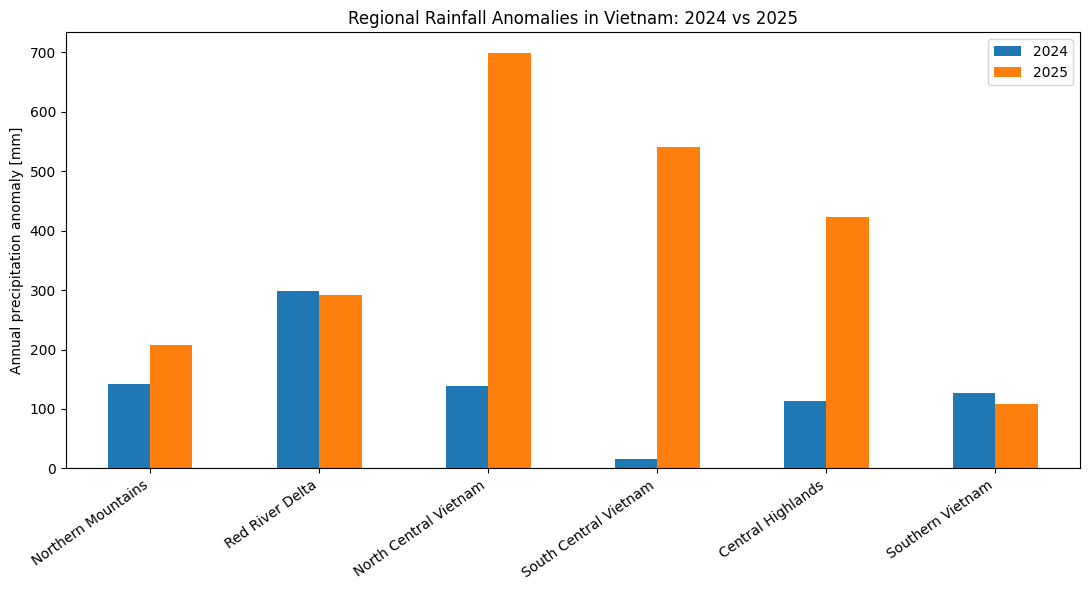

In [26]:
# Plot regional rainfall anomalies in 2024 and 2025
ax = regional_comparison.set_index("Region")[["2024", "2025"]].plot(
    kind="bar",
    figsize=(11, 6)
)

ax.axhline(0, linewidth=0.8)

ax.set_ylabel("Annual precipitation anomaly [mm]")
ax.set_xlabel("")
ax.set_title("Regional Rainfall Anomalies in Vietnam: 2024 vs 2025")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 4b: Monthly rainfall patterns

In [27]:
# Calculate monthly regional rainfall for 2024 and 2025

# Latitude weights for area-weighted regional means
lat_weights = np.cos(np.deg2rad(precip["latitude"]))

lat_weights = xr.DataArray(
    lat_weights,
    coords={"latitude": precip["latitude"]},
    dims=["latitude"]
)

monthly_comparison = {}

for region, mask in region_masks.items():

    regional_rainfall = (
        precip.where(mask)
        .weighted(lat_weights)
        .mean(dim=("latitude", "longitude"))
    )

    rainfall_2024 = regional_rainfall.sel(
        valid_time=slice("2024-01-01", "2024-12-31")
    )

    rainfall_2025 = regional_rainfall.sel(
        valid_time=slice("2025-01-01", "2025-12-31")
    )

    monthly_comparison[region] = {
        "2024": rainfall_2024,
        "2025": rainfall_2025
    }

print("Monthly comparison data created for:")
for region in monthly_comparison:
    print("-", region)

Monthly comparison data created for:
- Northern Mountains
- Red River Delta
- North Central Vietnam
- South Central Vietnam
- Central Highlands
- Southern Vietnam


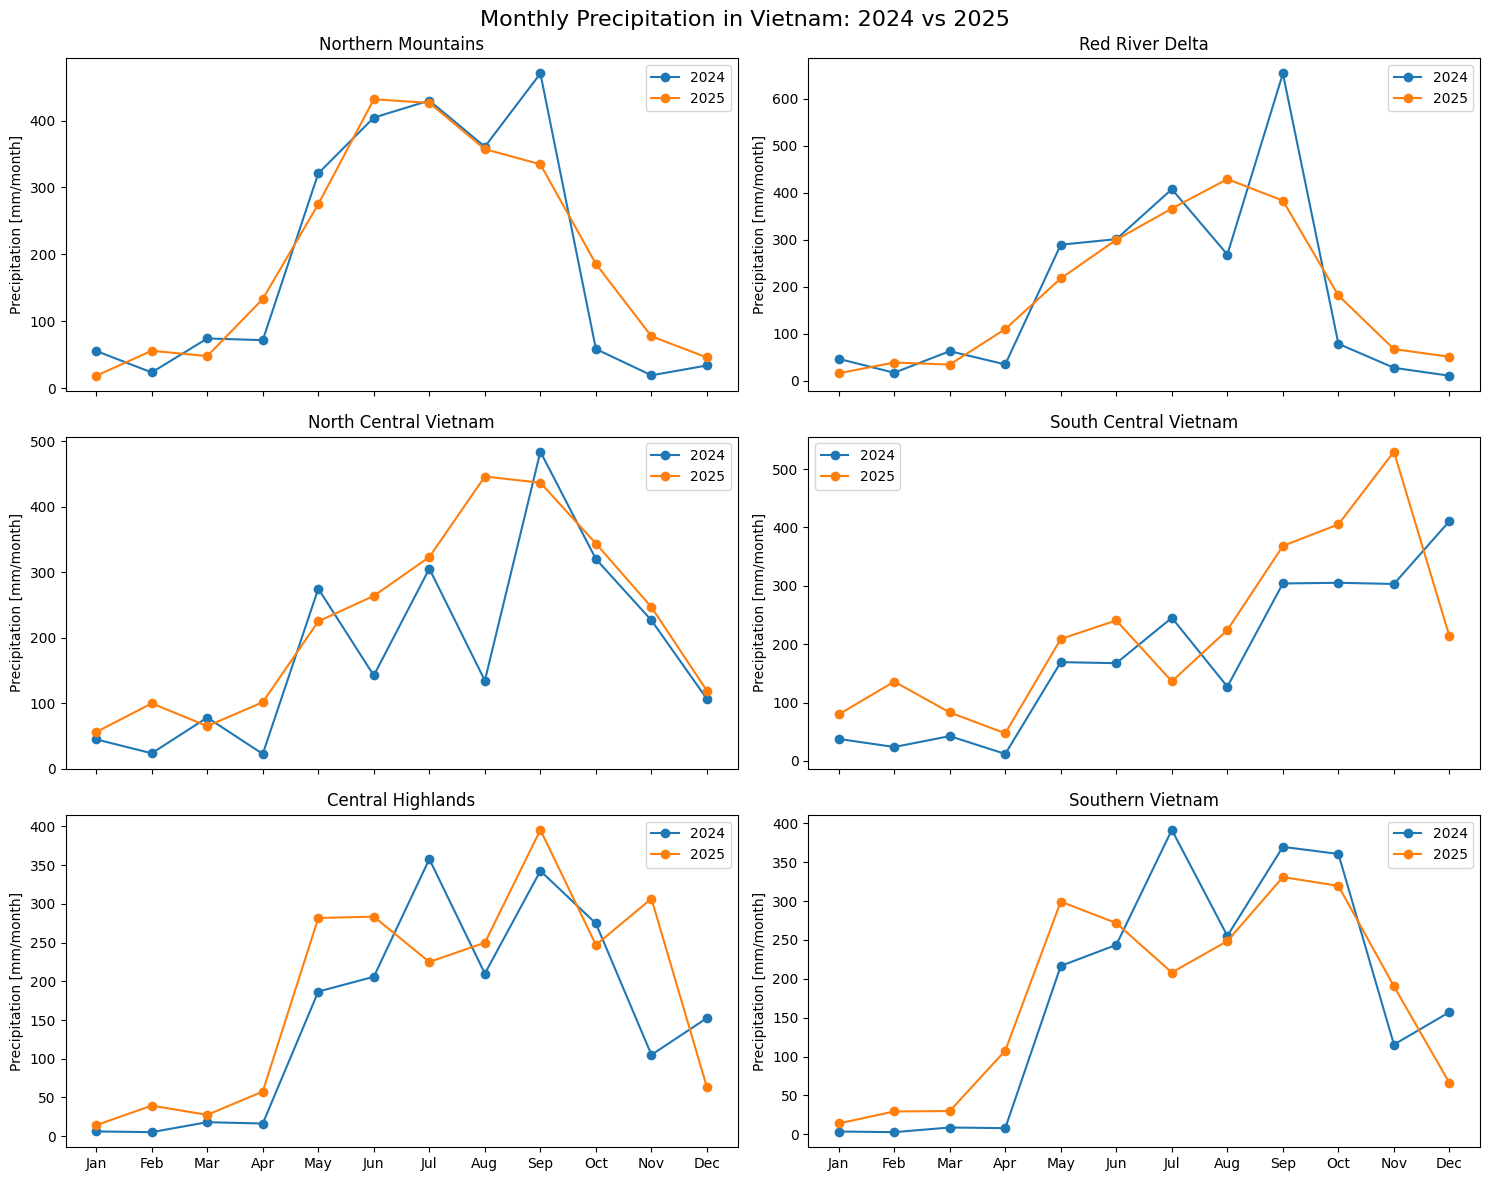

In [28]:
# Plot monthly rainfall in 2024 and 2025 for each region

fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 12),
    sharex=True
)

axes = axes.flatten()

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

for ax, region in zip(axes, regions.keys()):

    rainfall_2024 = monthly_comparison[region]["2024"]
    rainfall_2025 = monthly_comparison[region]["2025"]

    months = np.arange(1, 13)

    ax.plot(
        months,
        rainfall_2024.values,
        marker="o",
        label="2024"
    )

    ax.plot(
        months,
        rainfall_2025.values,
        marker="o",
        label="2025"
    )

    ax.set_title(region)
    ax.set_ylabel("Precipitation [mm/month]")
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    ax.legend()

plt.suptitle(
    "Monthly Precipitation in Vietnam: 2024 vs 2025",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 5: Spatial precipitation anomaly in 2025

To assess how unusual rainfall conditions were across Vietnam in 2025, annual precipitation in 2025 is compared with the long-term mean annual precipitation over 1950-2024.

The resulting anomaly map shows where 2025 was wetter or drier than the historical climate and highlights the spatial heterogeneity of rainfall conditions across Vietnam.

In [29]:
# Calculate historical annual precipitation baseline
annual_baseline_2025 = annual_precip.sel(
    year=slice(1950, 2024)
).mean(dim="year")

# Calculate 2025 annual precipitation anomaly
precip_2025_anomaly = (
    annual_precip.sel(year=2025)
    - annual_baseline_2025
)

# Mask to Vietnam
precip_2025_anomaly_vietnam = precip_2025_anomaly.where(
    Vietnam_mask
)

# Check anomaly range over Vietnam
print(
    "Minimum anomaly:",
    round(
        float(
            precip_2025_anomaly_vietnam.min(skipna=True)
        ),
        1
    ),
    "mm"
)

print(
    "Maximum anomaly:",
    round(
        float(
            precip_2025_anomaly_vietnam.max(skipna=True)
        ),
        1
    ),
    "mm"
)

Minimum anomaly: -349.4 mm
Maximum anomaly: 1367.2 mm


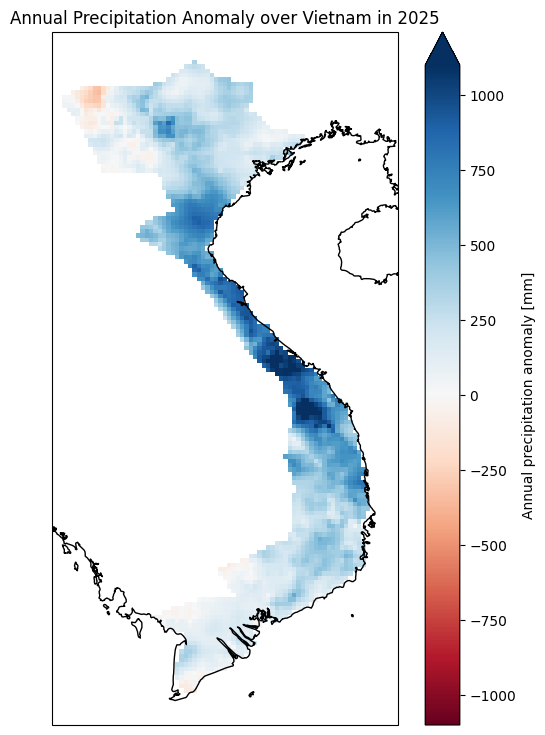

In [30]:
# Determine a robust symmetric colour scale
abs_anomaly = np.abs(
    precip_2025_anomaly_vietnam.values
)

color_limit = np.nanpercentile(
    abs_anomaly,
    98
)

color_limit = np.ceil(
    color_limit / 100
) * 100

# Plot 2025 annual precipitation anomaly over Vietnam
fig = plt.figure(figsize=(7, 9))

ax = plt.axes(projection=ccrs.PlateCarree())

precip_2025_anomaly_vietnam.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu",
    vmin=-color_limit,
    vmax=color_limit,
    cbar_kwargs={
        "label": "Annual precipitation anomaly [mm]"
    }
)

ax.coastlines()

ax.set_extent(
    [102, 110, 8, 24],
    crs=ccrs.PlateCarree()
)

plt.title(
    "Annual Precipitation Anomaly over Vietnam in 2025"
)

plt.show()

## 6: ENSO 3.4 sea surface temperature

### 6a: Load monthly sea surface temperature data

Monthly sea surface temperature data are loaded to construct an ENSO index based on the Niño 3.4 region.

In [31]:
# Define SST file path
sst_file = inputfolder / "ENSO" / "sst.mnmean.nc"

# Load monthly SST data
sst_ds = xr.open_dataset(sst_file)

sst = sst_ds["sst"]

print(
    "Time period:",
    str(sst.time.values[0])[:10],
    "to",
    str(sst.time.values[-1])[:10]
)

print(
    "Spatial coverage:",
    f"{float(sst.lat.min()):.1f}° to {float(sst.lat.max()):.1f}° latitude,",
    f"{float(sst.lon.min()):.1f}° to {float(sst.lon.max()):.1f}° longitude"
)

print("SST units:", sst.attrs.get("units", "unknown"))

Time period: 1854-01-01 to 2026-08-01
Spatial coverage: -88.0° to 88.0° latitude, 0.0° to 358.0° longitude
SST units: degC


### 6b: Calculate mean SST over the Niño 3.4 region

The Niño 3.4 region is defined as 5°S–5°N and 170°W–120°W. Because the SST dataset uses longitudes from 0° to 360°, this corresponds to 190°E–240°E.

Grid cells are weighted by the cosine of latitude when calculating the spatial mean.

In [32]:
# Extract Niño 3.4 region
sst_nino34 = sst.sel(
    lat=slice(5, -5),
    lon=slice(190, 240)
)

# Latitude weights for area-weighted spatial mean
weights = np.cos(np.deg2rad(sst_nino34["lat"]))

weights = xr.DataArray(
    weights,
    coords={"lat": sst_nino34["lat"]},
    dims=["lat"]
)

# Calculate area-weighted mean SST
Enso_34_raw = sst_nino34.weighted(
    weights
).mean(
    dim=("lat", "lon")
)

print(
    "Niño 3.4 SST period:",
    str(Enso_34_raw.time.values[0])[:10],
    "to",
    str(Enso_34_raw.time.values[-1])[:10]
)

print(
    "Mean Niño 3.4 SST:",
    round(float(Enso_34_raw.mean()), 2),
    "°C"
)

Niño 3.4 SST period: 1854-01-01 to 2026-08-01
Mean Niño 3.4 SST: 26.66 °C


### 6c: Construct the standardized Niño 3.4 index

The monthly climatological seasonal cycle is removed from the Niño 3.4 SST series to obtain SST anomalies. The anomaly series is then standardized to have a mean of zero and a standard deviation of one.

Positive values represent warmer-than-normal Niño 3.4 conditions, while negative values represent cooler-than-normal conditions.

In [33]:
# Calculate monthly SST climatology
nino34_climatology = Enso_34_raw.groupby(
    "time.month"
).mean(
    dim="time"
)

# Calculate monthly SST anomalies
Enso_34_anomaly = (
    Enso_34_raw.groupby("time.month")
    - nino34_climatology
)

# Standardize the anomaly series
Enso_34 = (
    Enso_34_anomaly
    - Enso_34_anomaly.mean()
) / Enso_34_anomaly.std()

print(
    "Standardized ENSO mean:",
    round(float(Enso_34.mean()), 3)
)

print(
    "Standardized ENSO standard deviation:",
    round(float(Enso_34.std()), 3)
)

Standardized ENSO mean: -0.0
Standardized ENSO standard deviation: 1.0


## 7: Link between ENSO and rainfall in Vietnam

To examine whether ENSO is associated with rainfall variability across Vietnam, monthly precipitation is first aggregated across six regions.

Monthly rainfall anomalies are then standardized and compared with the standardized Niño 3.4 index over the common period 1950–2025.

### 7a: Regional monthly precipitation

Area-weighted monthly precipitation is calculated for each of the six regions of Vietnam. Latitude-based cosine weights are used to account for differences in grid-cell area.

In [34]:
# Latitude weights for area-weighted regional means
lat_weights = np.cos(
    np.deg2rad(precip["latitude"])
)

lat_weights = xr.DataArray(
    lat_weights,
    coords={"latitude": precip["latitude"]},
    dims=["latitude"]
)

# Calculate regional monthly precipitation
regional_monthly = {}

for region, mask in region_masks.items():

    regional_monthly[region] = (
        precip.where(mask)
        .weighted(lat_weights)
        .mean(dim=("latitude", "longitude"))
        .rename({"valid_time": "time"})
    )

print("Regional monthly precipitation calculated for:")
for region in regional_monthly:
    print("-", region)

Regional monthly precipitation calculated for:
- Northern Mountains
- Red River Delta
- North Central Vietnam
- South Central Vietnam
- Central Highlands
- Southern Vietnam


In [35]:
# Select the common study period
Enso_34_study = Enso_34.sel(
    time=slice("1950-01-01", "2025-12-31")
)

regional_monthly_study = {}

for region, rainfall in regional_monthly.items():

    rainfall = rainfall.sel(
        time=slice("1950-01-01", "2025-12-31")
    )

    rainfall_aligned, enso_aligned = xr.align(
        rainfall,
        Enso_34_study,
        join="inner"
    )

    regional_monthly_study[region] = rainfall_aligned

# Use the common ENSO series
Enso_34_aligned = enso_aligned

print(
    "Common period:",
    str(Enso_34_aligned.time.values[0])[:10],
    "to",
    str(Enso_34_aligned.time.values[-1])[:10]
)

print(
    "Number of months:",
    Enso_34_aligned.sizes["time"]
)

Common period: 1950-01-01 to 2025-12-01
Number of months: 912


### 7b: Standardized monthly rainfall anomalies

For each region, the monthly climatological seasonal cycle is removed to obtain precipitation anomalies.

The anomalies are then standardized to have a mean of zero and a standard deviation of one, allowing rainfall variability to be compared consistently with the standardized Niño 3.4 index.

In [36]:
# Calculate standardized monthly rainfall anomalies
regional_rainfall_std = {}

for region, rainfall in regional_monthly_study.items():

    # Remove the monthly climatological seasonal cycle
    monthly_climatology = rainfall.groupby(
        "time.month"
    ).mean(
        dim="time"
    )

    rainfall_anomaly = (
        rainfall.groupby("time.month")
        - monthly_climatology
    )

    # Standardize anomalies
    rainfall_standardized = (
        rainfall_anomaly
        - rainfall_anomaly.mean()
    ) / rainfall_anomaly.std()

    regional_rainfall_std[region] = rainfall_standardized

In [37]:
# Check standardized regional rainfall series
for region, series in regional_rainfall_std.items():
    print(
        f"{region}: "
        f"mean = {float(series.mean()):.3f}, "
        f"std = {float(series.std()):.3f}"
    )

Northern Mountains: mean = 0.000, std = 1.000
Red River Delta: mean = 0.000, std = 1.000
North Central Vietnam: mean = 0.000, std = 1.000
South Central Vietnam: mean = -0.000, std = 1.000
Central Highlands: mean = -0.000, std = 1.000
Southern Vietnam: mean = 0.000, std = 1.000


### 7c: Same-month ENSO–rainfall correlation

A Pearson correlation test is used to examine the same-month relationship between the standardized Niño 3.4 index and regional rainfall anomalies.

- **H₀:** There is no linear correlation between ENSO and regional rainfall anomalies.
- **H₁:** There is a linear correlation between ENSO and regional rainfall anomalies.

A significance level of **α = 0.05** is used. If p < 0.05, H₀ is rejected; otherwise, H₀ is not rejected.

This analysis uses contemporaneous values (lag 0) as a preliminary assessment before the SPI analysis.

In [38]:
# Calculate same-month Pearson correlations
alpha = 0.05

enso_rainfall_results = []

for region, rainfall in regional_rainfall_std.items():

    rainfall_aligned, enso_aligned = xr.align(
        rainfall,
        Enso_34_aligned,
        join="inner"
    )

    r, p = stats.pearsonr(
        enso_aligned.values,
        rainfall_aligned.values
    )

    decision = (
        "Reject H0"
        if p < alpha
        else "Do not reject H0"
    )

    enso_rainfall_results.append({
        "Region": region,
        "Correlation": r,
        "p-value": p,
        "Decision": decision
    })

enso_rainfall_results = pd.DataFrame(
    enso_rainfall_results
)

enso_rainfall_results

,Region,Correlation,p-value,Decision
0,Northern Mountains,0.001529,9.632289e-01,Do not reject H0
1,Red River Delta,-0.021519,5.163050e-01,Do not reject H0
2,North Central Vietnam,-0.147741,7.458471e-06,Reject H0
3,South Central Vietnam,-0.261975,8.875470e-16,Reject H0
4,Central Highlands,-0.178668,5.571901e-08,Reject H0
5,Southern Vietnam,-0.213329,7.583816e-11,Reject H0


As a sensitivity check, lagged correlations are also tested at 1, 3, and 6 months. A positive lag means that ENSO leads regional rainfall by the specified number of months.

In [39]:
# Sensitivity check: lagged ENSO-rainfall correlations

lags = [1, 3, 6]

lagged_results = []

for region, rainfall in regional_rainfall_std.items():

    for lag in lags:

        # Positive lag means ENSO leads rainfall
        enso_lagged = Enso_34_aligned.shift(
            time=lag
        )

        rainfall_aligned, enso_aligned = xr.align(
            rainfall,
            enso_lagged,
            join="inner"
        )

        # Remove missing values introduced by shifting
        valid = (
            np.isfinite(rainfall_aligned.values)
            & np.isfinite(enso_aligned.values)
        )

        rainfall_values = rainfall_aligned.values[valid]
        enso_values = enso_aligned.values[valid]

        r, p = stats.pearsonr(
            enso_values,
            rainfall_values
        )

        decision = (
            "Reject H0"
            if p < 0.05
            else "Do not reject H0"
        )

        lagged_results.append({
            "Region": region,
            "Lag (months)": lag,
            "Correlation": r,
            "p-value": p,
            "Decision": decision
        })

lagged_results = pd.DataFrame(
    lagged_results
)

lagged_results

,Region,Lag (months),Correlation,p-value,Decision
0,Northern Mountains,1,0.002312,9.444421e-01,Do not reject H0
1,Northern Mountains,3,-0.011160,7.368541e-01,Do not reject H0
2,Northern Mountains,6,-0.025168,4.492662e-01,Do not reject H0
3,Red River Delta,1,-0.015568,6.388830e-01,Do not reject H0
4,Red River Delta,3,-0.029905,3.678045e-01,Do not reject H0
5,Red River Delta,6,-0.027478,4.087514e-01,Do not reject H0
6,North Central Vietnam,1,-0.119085,3.155424e-04,Reject H0
7,North Central Vietnam,3,-0.110292,8.658411e-04,Reject H0
8,North Central Vietnam,6,-0.064015,5.408517e-02,Do not reject H0
9,South Central Vietnam,1,-0.221821,1.283256e-11,Reject H0


## 8: Standardized Precipitation Index (SPI)

The Standardized Precipitation Index (SPI) is used to characterize wet and dry conditions over different precipitation accumulation periods.

SPI is calculated by:

1. accumulating precipitation over a selected time scale;
2. fitting a Gamma distribution to the accumulated precipitation for each calendar month;
3. converting the cumulative probabilities to the corresponding values of a standard normal distribution.

Positive SPI values indicate wetter-than-normal conditions, while negative values indicate drier-than-normal conditions. Multiple accumulation periods are examined to assess how the ENSO–rainfall relationship varies across different time scales.

### 8a: Effect of precipitation accumulation period

SPI can be calculated over different accumulation periods. Shorter accumulation periods reflect relatively short-term rainfall variability, while longer periods smooth short-term fluctuations and represent more persistent wet or dry conditions.

The example below illustrates the effect of 3- and 6-month precipitation accumulation for South Central Vietnam.

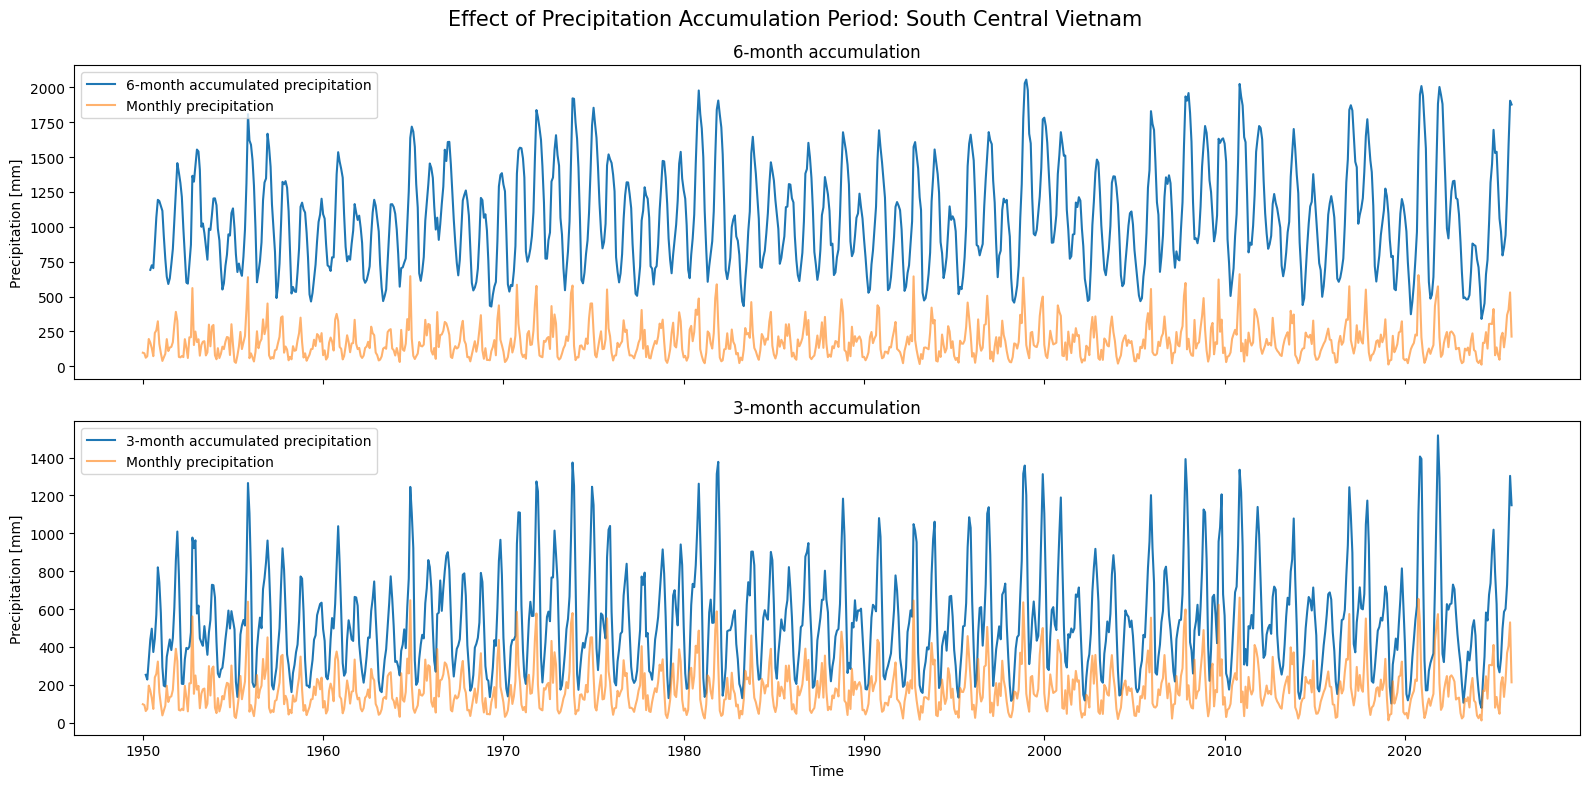

In [40]:
# Select a representative region
region = "South Central Vietnam"

rainfall = regional_monthly_study[region].to_series()

# Calculate accumulated precipitation
rainfall_3month = rainfall.rolling(
    window=3,
    min_periods=3
).sum()

rainfall_6month = rainfall.rolling(
    window=6,
    min_periods=6
).sum()

# Plot the effect of different accumulation periods
fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    sharex=True
)

# 6-month accumulation
axes[0].plot(
    rainfall_6month.index,
    rainfall_6month.values,
    label="6-month accumulated precipitation"
)

axes[0].plot(
    rainfall.index,
    rainfall.values,
    alpha=0.6,
    label="Monthly precipitation"
)

axes[0].set_ylabel("Precipitation [mm]")
axes[0].set_title("6-month accumulation")
axes[0].legend()

# 3-month accumulation
axes[1].plot(
    rainfall_3month.index,
    rainfall_3month.values,
    label="3-month accumulated precipitation"
)

axes[1].plot(
    rainfall.index,
    rainfall.values,
    alpha=0.6,
    label="Monthly precipitation"
)

axes[1].set_ylabel("Precipitation [mm]")
axes[1].set_title("3-month accumulation")
axes[1].set_xlabel("Time")
axes[1].legend()

plt.suptitle(
    f"Effect of Precipitation Accumulation Period: {region}",
    fontsize=15
)

plt.tight_layout()
plt.show()

### 8b: Gamma distribution fit and diagnostic

SPI requires a probability distribution to be fitted to accumulated precipitation.

The analysis begins with a one-month accumulation period, which corresponds to monthly precipitation. Because rainfall seasonality differs throughout the year, a Gamma distribution is fitted separately for each calendar month.

The example below illustrates the Gamma fit for October precipitation in South Central Vietnam. The fitted distribution is evaluated using a Kolmogorov–Smirnov (K–S) test and visual diagnostics. If p > 0.05, the Gamma distribution is not rejected.

In [41]:
# Select representative region, accumulation period, and calendar month
region = "South Central Vietnam"
accumulation = 1
month = 10

month_name = pd.Timestamp(
    year=2000,
    month=month,
    day=1
).strftime("%B")

# Convert regional rainfall series to pandas Series
rainfall = regional_monthly_study[region].to_series()

# Calculate accumulated precipitation
rainfall_accumulated = rainfall.rolling(
    window=accumulation,
    min_periods=accumulation
).sum()

# Select the same calendar month across all years
month_data = rainfall_accumulated[
    rainfall_accumulated.index.month == month
].dropna()

# Fit Gamma distribution
shape, loc, scale = stats.gamma.fit(
    month_data.values,
    floc=0
)

gamma_dist = stats.gamma(
    shape,
    loc=loc,
    scale=scale
)

# Kolmogorov-Smirnov test
ks_stat, ks_pvalue = stats.kstest(
    month_data.values,
    "gamma",
    args=(shape, loc, scale)
)

# Print summary
print("Region:", region)
print("Accumulation period:", accumulation, "month")
print("Calendar month:", month_name)
print("Number of observations:", len(month_data))
print("K-S statistic:", round(ks_stat, 3))
print("K-S p-value:", round(ks_pvalue, 3))

if ks_pvalue < 0.05:
    print("Decision: Reject Gamma fit")
else:
    print("Decision: Do not reject Gamma fit")

Region: South Central Vietnam
Accumulation period: 1 month
Calendar month: October
Number of observations: 76
K-S statistic: 0.068
K-S p-value: 0.851
Decision: Do not reject Gamma fit


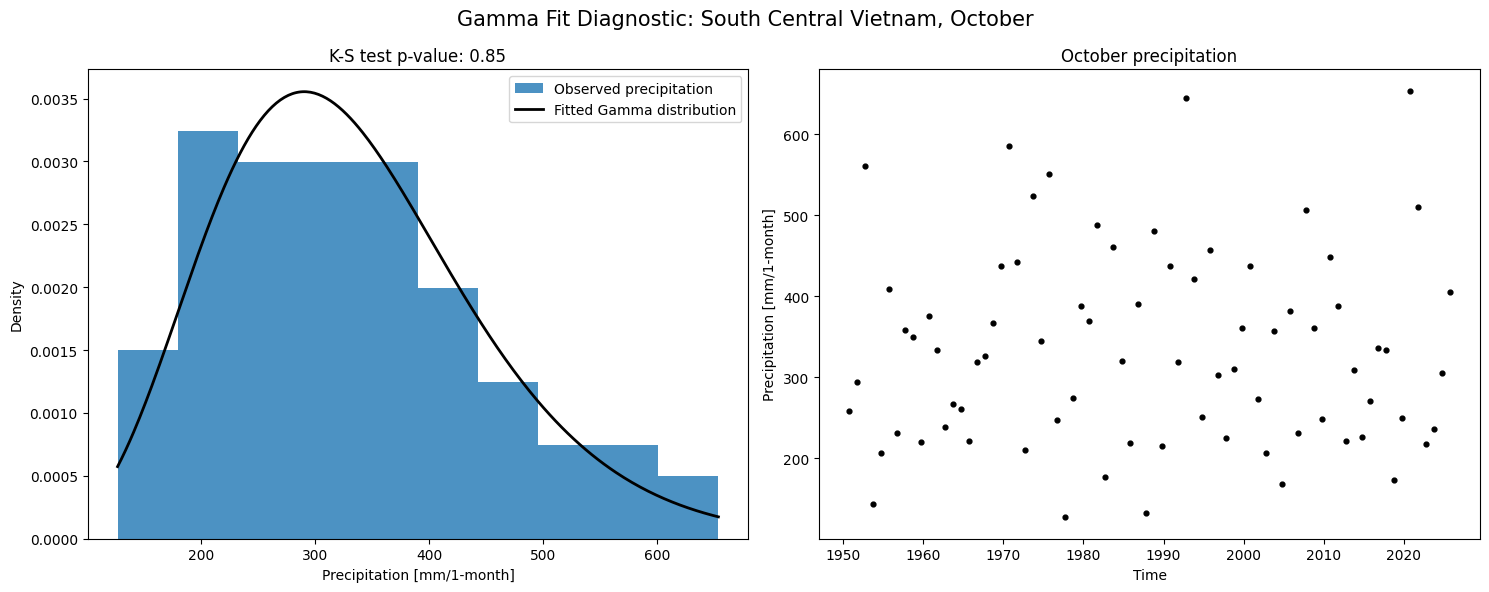

In [42]:
# Generate values for the fitted Gamma density
x = np.linspace(
    month_data.min(),
    month_data.max(),
    300
)

# Plot Gamma fit diagnostics
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# Left panel: observed distribution and fitted Gamma density
axes[0].hist(
    month_data.values,
    bins=10,
    density=True,
    alpha=0.8,
    label="Observed precipitation"
)

axes[0].plot(
    x,
    gamma_dist.pdf(x),
    color="black",
    linewidth=2,
    label="Fitted Gamma distribution"
)

axes[0].set_title(
    f"K-S test p-value: {ks_pvalue:.2f}"
)

axes[0].set_xlabel(
    "Precipitation [mm/1-month]"
)

axes[0].set_ylabel("Density")
axes[0].legend()

# Right panel: October precipitation through time
axes[1].scatter(
    month_data.index,
    month_data.values,
    s=12,
    color="black"
)

axes[1].set_title(
    f"{month_name} precipitation"
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel(
    "Precipitation [mm/1-month]"
)

plt.suptitle(
    f"Gamma Fit Diagnostic: {region}, {month_name}",
    fontsize=15
)

plt.tight_layout()
plt.show()

### 8c: Transform precipitation probabilities to SPI

After fitting the Gamma distribution, each precipitation value is converted to its cumulative probability under the fitted distribution.

These cumulative probabilities are then transformed to the corresponding quantiles of a standard normal distribution. The resulting standardized values are the SPI.

Positive SPI values indicate wetter-than-normal conditions, while negative values indicate drier-than-normal conditions.

In [43]:
# Convert precipitation values to cumulative probabilities
gamma_probabilities = gamma_dist.cdf(
    month_data.values
)

# Avoid probabilities exactly equal to 0 or 1
gamma_probabilities = np.clip(
    gamma_probabilities,
    1e-6,
    1 - 1e-6
)

# Transform Gamma probabilities to standard normal values
spi_values = stats.norm.ppf(
    gamma_probabilities
)

# Limit extreme SPI values
spi_values = np.clip(
    spi_values,
    -3,
    3
)

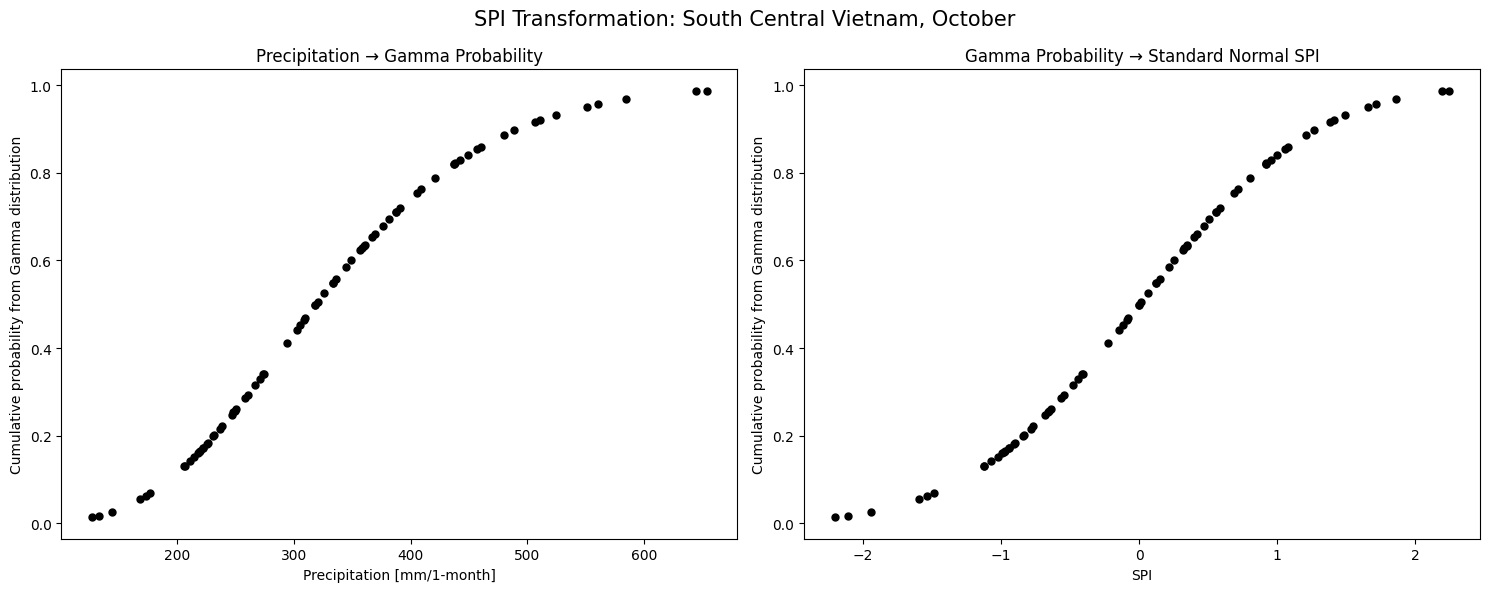

In [44]:
# Plot precipitation-to-probability and probability-to-SPI transformations

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# Left panel: precipitation vs Gamma cumulative probability
axes[0].scatter(
    month_data.values,
    gamma_probabilities,
    s=25,
    color="black"
)

axes[0].set_xlabel(
    "Precipitation [mm/1-month]"
)

axes[0].set_ylabel(
    "Cumulative probability from Gamma distribution"
)

axes[0].set_title(
    "Precipitation → Gamma Probability"
)

# Right panel: SPI vs Gamma cumulative probability
axes[1].scatter(
    spi_values,
    gamma_probabilities,
    s=25,
    color="black"
)

axes[1].set_xlabel(
    "SPI"
)

axes[1].set_ylabel(
    "Cumulative probability from Gamma distribution"
)

axes[1].set_title(
    "Gamma Probability → Standard Normal SPI"
)

plt.suptitle(
    f"SPI Transformation: {region}, {month_name}",
    fontsize=15
)

plt.tight_layout()
plt.show()

### 8d: Calculate SPI across regions and accumulation periods

The SPI transformation is now applied to the complete regional precipitation series.

For each region and accumulation period, precipitation is accumulated over the selected time window. A Gamma distribution is then fitted separately for each calendar month, and the cumulative probabilities are transformed to standard normal values.

SPI is calculated for 1-, 3-, 6-, and 24-month accumulation periods to examine rainfall variability across different time scales.

In [45]:
def calc_spi(series):
    """
    Calculate SPI for one precipitation series using a Gamma distribution.
    """

    series = series.dropna()

    values = series.values

    # Identify zero and non-zero precipitation values
    nonzero = values > 0

    n_zero = np.sum(~nonzero)
    ratio_zero = n_zero / len(values)

    # Fit Gamma distribution to non-zero precipitation
    shape, loc, scale = stats.gamma.fit(
        values[nonzero],
        floc=0
    )

    gamma_dist = stats.gamma(
        shape,
        loc=loc,
        scale=scale
    )

    # Calculate cumulative probabilities
    probabilities = np.full(
        len(values),
        np.nan
    )

    probabilities[nonzero] = (
        ratio_zero
        + (1 - ratio_zero)
        * gamma_dist.cdf(values[nonzero])
    )

    # Probability assigned to zero precipitation values
    if n_zero > 0:
        probabilities[~nonzero] = (
            n_zero + 1
        ) / (
            2 * (len(values) + 1)
        )

    # Avoid probabilities exactly equal to 0 or 1
    probabilities = np.clip(
        probabilities,
        1e-6,
        1 - 1e-6
    )

    # Transform to standard normal distribution
    spi = stats.norm.ppf(
        probabilities
    )

    # Limit extreme SPI values
    spi = np.clip(
        spi,
        -3,
        3
    )

    return pd.Series(
        spi,
        index=series.index
    )

In [46]:
def calculate_regional_spi(
    regional_rainfall,
    accumulation
):
    """
    Calculate SPI for all regions at a selected
    precipitation accumulation period.
    """

    regional_spi = {}

    for region, rainfall in regional_rainfall.items():

        rainfall_series = rainfall.to_series()

        # Accumulate precipitation
        rainfall_accumulated = rainfall_series.rolling(
            window=accumulation,
            min_periods=accumulation
        ).sum()

        spi = pd.Series(
            index=rainfall_accumulated.index,
            dtype=float
        )

        # Fit the Gamma distribution separately
        # for each calendar month
        for month in range(1, 13):

            month_data = rainfall_accumulated[
                rainfall_accumulated.index.month == month
            ].dropna()

            spi.loc[
                month_data.index
            ] = calc_spi(
                month_data
            )

        regional_spi[region] = spi.sort_index()

    return regional_spi


# Calculate SPI at multiple accumulation periods
spi_periods = [1, 3, 6, 24]

regional_spi = {}

for period in spi_periods:

    regional_spi[period] = calculate_regional_spi(
        regional_monthly_study,
        accumulation=period
    )

print(
    "SPI calculated for accumulation periods:",
    spi_periods
)

SPI calculated for accumulation periods: [1, 3, 6, 24]


In [169]:
# Check SPI distributions by region and accumulation period

for period in spi_periods:

    print(f"\nSPI-{period}")

    for region, spi in regional_spi[period].items():

        print(
            region,
            "| mean:",
            round(spi.mean(), 3),
            "| std:",
            round(spi.std(), 3),
            "| min:",
            round(spi.min(), 2),
            "| max:",
            round(spi.max(), 2)
        )


SPI-1
Northern Mountains | mean: 0.002 | std: 0.991 | min: -3.0 | max: 3.0
Red River Delta | mean: -0.001 | std: 0.997 | min: -3.0 | max: 3.0
North Central Vietnam | mean: -0.004 | std: 0.982 | min: -3.0 | max: 3.0
South Central Vietnam | mean: -0.002 | std: 0.999 | min: -2.94 | max: 3.0
Central Highlands | mean: -0.004 | std: 0.991 | min: -3.0 | max: 3.0
Southern Vietnam | mean: -0.0 | std: 0.995 | min: -3.0 | max: 2.55

SPI-3
Northern Mountains | mean: 0.008 | std: 0.967 | min: -3.0 | max: 3.0
Red River Delta | mean: -0.001 | std: 0.993 | min: -3.0 | max: 3.0
North Central Vietnam | mean: -0.006 | std: 0.976 | min: -3.0 | max: 3.0
South Central Vietnam | mean: -0.001 | std: 1.0 | min: -2.55 | max: 2.93
Central Highlands | mean: -0.001 | std: 1.0 | min: -2.85 | max: 3.0
Southern Vietnam | mean: 0.001 | std: 0.998 | min: -3.0 | max: 2.49

SPI-6
Northern Mountains | mean: 0.019 | std: 0.928 | min: -3.0 | max: 2.58
Red River Delta | mean: 0.005 | std: 0.983 | min: -3.0 | max: 3.0
North 

### 8e: ENSO–SPI correlation

Pearson correlation tests are used to examine the relationship between the standardized Niño 3.4 index and regional SPI values.

The hypotheses are:

- **H₀:** There is no linear correlation between ENSO and SPI.
- **H₁:** There is a linear correlation between ENSO and SPI.

A significance level of **α = 0.05** is used. If p < 0.05, H₀ is rejected; otherwise, H₀ is not rejected.

The analysis is repeated for SPI-1, SPI-3, SPI-6, and SPI-24 to assess how the ENSO–rainfall relationship varies across different accumulation periods.

In [47]:
# Calculate Pearson correlations between ENSO and SPI

alpha = 0.05

enso_spi_results = []

for period in spi_periods:

    for region, spi in regional_spi[period].items():

        # Convert SPI to xarray for alignment
        spi_xr = xr.DataArray(
            spi.values,
            coords={"time": spi.index},
            dims=["time"]
        )

        spi_aligned, enso_aligned = xr.align(
            spi_xr,
            Enso_34_aligned,
            join="inner"
        )

        # Remove missing values
        valid = (
            np.isfinite(spi_aligned.values)
            & np.isfinite(enso_aligned.values)
        )

        spi_values = spi_aligned.values[valid]
        enso_values = enso_aligned.values[valid]

        # Pearson correlation
        r, p = stats.pearsonr(
            enso_values,
            spi_values
        )

        decision = (
            "Reject H0"
            if p < alpha
            else "Do not reject H0"
        )

        enso_spi_results.append({
            "SPI": f"SPI-{period}",
            "Region": region,
            "Correlation": r,
            "p-value": p,
            "Decision": decision
        })

enso_spi_results = pd.DataFrame(
    enso_spi_results
)

enso_spi_results

,SPI,Region,Correlation,p-value,Decision
0,SPI-1,Northern Mountains,0.036805,2.668593e-01,Do not reject H0
1,SPI-1,Red River Delta,0.054170,1.020779e-01,Do not reject H0
2,SPI-1,North Central Vietnam,-0.126274,1.315764e-04,Reject H0
3,SPI-1,South Central Vietnam,-0.222844,1.001554e-11,Reject H0
4,SPI-1,Central Highlands,-0.186777,1.324283e-08,Reject H0
5,SPI-1,Southern Vietnam,-0.241545,1.422219e-13,Reject H0
6,SPI-3,Northern Mountains,0.017716,5.935242e-01,Do not reject H0
7,SPI-3,Red River Delta,0.021521,5.167350e-01,Do not reject H0
8,SPI-3,North Central Vietnam,-0.234045,8.672364e-13,Reject H0
9,SPI-3,South Central Vietnam,-0.342414,1.975147e-26,Reject H0


## 9: Spatial dependence of ENSO impact

Regional averages can hide important spatial differences in the relationship between ENSO and precipitation.

To examine this spatial heterogeneity, SPI-6 is calculated at each grid cell across Vietnam. The Pearson correlation between the standardized Niño 3.4 index and SPI-6 is then calculated separately for every grid cell.

Statistically significant correlations at the 5% level are indicated on the spatial map.

### 9a: Calculate SPI-6 at each grid cell

To examine spatial variations in the ENSO–precipitation relationship, SPI-6 is calculated separately for each grid cell across Vietnam.

For each grid cell, six-month accumulated precipitation is calculated and a Gamma distribution is fitted separately for each calendar month. The resulting cumulative probabilities are then transformed to SPI values.

In [56]:
# Restrict precipitation to Vietnam and the study period
precip_vietnam_study = (
    pr_vietnam
    .sel(
        valid_time=slice(
            "1950-01-01",
            "2025-12-31"
        )
    )
    .rename(
        {"valid_time": "time"}
    )
)

# Stack latitude and longitude into a single grid-cell dimension
precip_stacked = precip_vietnam_study.stack(
    gridcell=("latitude", "longitude")
)

# Remove grid cells that contain no precipitation data
precip_stacked = precip_stacked.dropna(
    dim="gridcell",
    how="all"
)

print(
    "Number of Vietnam grid cells:",
    precip_stacked.sizes["gridcell"]
)

print(
    "Number of months:",
    precip_stacked.sizes["time"]
)

Number of Vietnam grid cells: 2776
Number of months: 912


In [57]:
# Calculate SPI-6 at each grid cell

accumulation = 6

spi6_grid = xr.full_like(
    precip_stacked,
    np.nan,
    dtype=float
)

for i in range(
    precip_stacked.sizes["gridcell"]
):

    rainfall_series = (
        precip_stacked
        .isel(gridcell=i)
        .to_series()
    )

    # Calculate six-month accumulated precipitation
    rainfall_accumulated = rainfall_series.rolling(
        window=accumulation,
        min_periods=accumulation
    ).sum()

    spi_series = pd.Series(
        index=rainfall_accumulated.index,
        dtype=float
    )

    # Fit Gamma distribution separately for each calendar month
    for month in range(1, 13):

        month_data = rainfall_accumulated[
            rainfall_accumulated.index.month == month
        ].dropna()

        if len(month_data) > 0:

            spi_series.loc[
                month_data.index
            ] = calc_spi(
                month_data
            )

    spi6_grid[:, i] = spi_series.values

In [58]:
# Restore the original spatial grid
spi6_grid = spi6_grid.unstack(
    "gridcell"
)

spi6_grid.name = "SPI-6"

print(
    "SPI-6 dimensions:",
    dict(spi6_grid.sizes)
)

print(
    "Time period:",
    str(spi6_grid.time.values[0])[:10],
    "to",
    str(spi6_grid.time.values[-1])[:10]
)

SPI-6 dimensions: {'time': 912, 'latitude': 146, 'longitude': 71}
Time period: 1950-01-01 to 2025-12-01


9b: Grid-cell ENSO–SPI-6 correlation
The relationship between ENSO and SPI-6 is examined at both the national and grid-cell levels. A national SPI-6 time series is first constructed by taking the area-weighted spatial mean of SPI-6 across Vietnam and standardizing the resulting series. This provides an overall view of the historical relationship between ENSO and six-month precipitation conditions.
The relationship is then calculated separately at each grid cell across Vietnam. For each grid cell, a Pearson correlation test is applied between the standardized Niño 3.4 index and SPI-6 over the common 1950–2025 period. The resulting correlation coefficient measures the direction and strength of the relationship, while the p-value is used to identify statistically significant correlations at the 5% level.

Vietnam ENSO–SPI-6 correlation: r = -0.253, p = 1.09e-14, r² = 6.4%


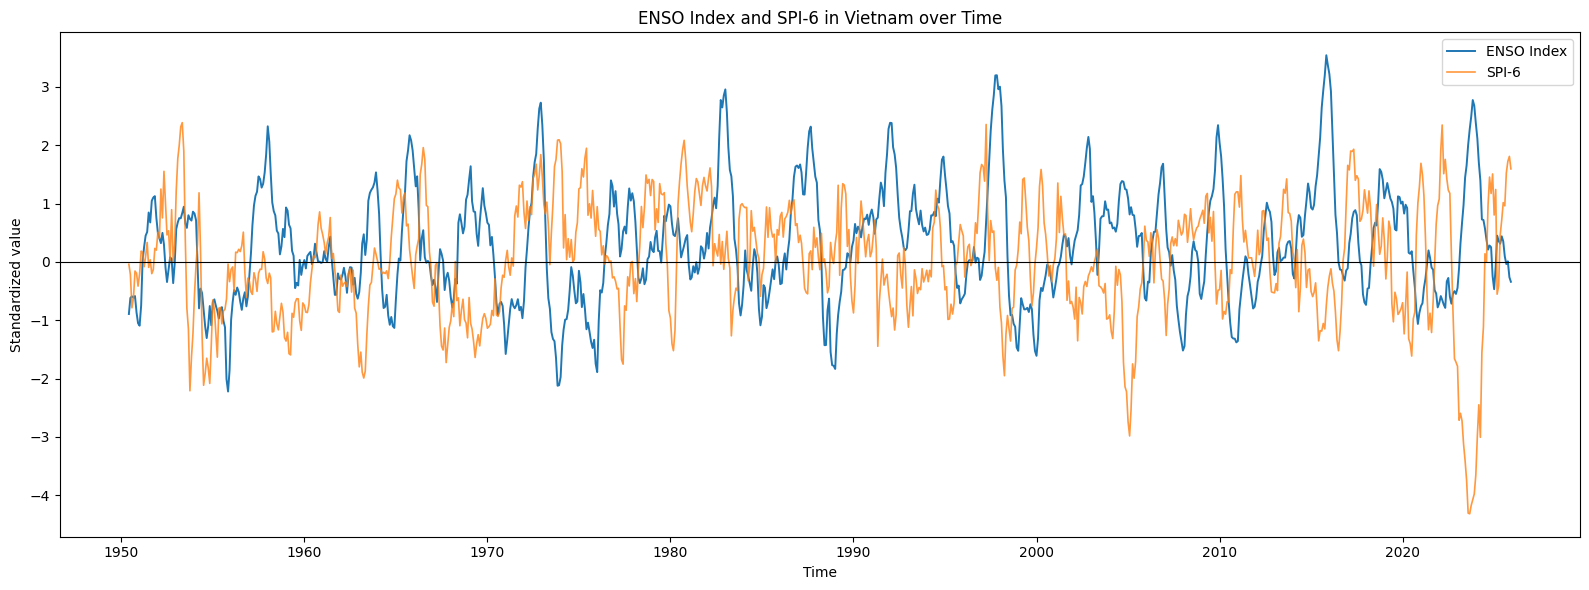

In [59]:
# Calculate national SPI-6 time series from grid-cell SPI-6

# Latitude weights
lat_weights = np.cos(
    np.deg2rad(spi6_grid["latitude"])
)

# Area-weighted spatial mean across Vietnam
SPI_6_Vietnam_ts = (
    spi6_grid
    .weighted(lat_weights)
    .mean(
        dim=("latitude", "longitude"),
        skipna=True
    )
)

# Re-standardize after spatial averaging
SPI_6_Vietnam_ts = (
    SPI_6_Vietnam_ts - SPI_6_Vietnam_ts.mean()
) / SPI_6_Vietnam_ts.std()

# Align national SPI-6 with ENSO
spi6_vietnam_aligned, enso_vietnam_aligned = xr.align(
    SPI_6_Vietnam_ts,
    Enso_34_aligned,
    join="inner"
)

# Remove missing observations
valid = (
    np.isfinite(spi6_vietnam_aligned.values)
    & np.isfinite(enso_vietnam_aligned.values)
)

dates = pd.to_datetime(
    spi6_vietnam_aligned.time.values[valid]
)

spi_values = spi6_vietnam_aligned.values[valid]
enso_values = enso_vietnam_aligned.values[valid]

# Pearson correlation
r_vietnam, p_vietnam = stats.pearsonr(
    enso_values,
    spi_values
)

print(
    f"Vietnam ENSO–SPI-6 correlation: "
    f"r = {r_vietnam:.3f}, "
    f"p = {p_vietnam:.3g}, "
    f"r² = {r_vietnam**2 * 100:.1f}%"
)

# Plot national ENSO and SPI-6 time series
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    dates,
    enso_values,
    linewidth=1.4,
    label="ENSO Index"
)

ax.plot(
    dates,
    spi_values,
    linewidth=1.2,
    alpha=0.8,
    label="SPI-6"
)

ax.axhline(
    0,
    linewidth=0.8,
    color="black"
)

ax.set_xlabel("Time")
ax.set_ylabel("Standardized value")

ax.set_title(
    "ENSO Index and SPI-6 in Vietnam over Time"
)

ax.legend()

plt.tight_layout()
plt.show()

In [60]:
# Align ENSO and gridded SPI-6 over the common time period
spi6_aligned, enso_grid_aligned = xr.align(
    spi6_grid,
    Enso_34_aligned,
    join="inner"
)

# Prepare arrays for correlation coefficients and p-values
correlation_map = xr.full_like(
    spi6_aligned.isel(time=0),
    np.nan,
    dtype=float
)

pvalue_map = xr.full_like(
    spi6_aligned.isel(time=0),
    np.nan,
    dtype=float
)

# Calculate Pearson correlation at each grid cell
for i in range(spi6_aligned.sizes["latitude"]):

    for j in range(spi6_aligned.sizes["longitude"]):

        spi_series = spi6_aligned[:, i, j].values
        enso_series = enso_grid_aligned.values

        valid = (
            np.isfinite(spi_series)
            & np.isfinite(enso_series)
        )

        if valid.sum() > 2:

            r, p = stats.pearsonr(
                enso_series[valid],
                spi_series[valid]
            )

            correlation_map[i, j] = r
            pvalue_map[i, j] = p

correlation_map.name = "ENSO-SPI6 correlation"
pvalue_map.name = "p-value"

In [61]:
# Summarize spatial correlation results
valid_correlations = correlation_map.values[
    np.isfinite(correlation_map.values)
]

significant_cells = (
    np.isfinite(pvalue_map.values)
    & (pvalue_map.values < 0.05)
)

print(
    "Correlation range:",
    round(float(np.nanmin(valid_correlations)), 3),
    "to",
    round(float(np.nanmax(valid_correlations)), 3)
)

print(
    "Significant grid cells (p < 0.05):",
    int(significant_cells.sum())
)

print(
    "Share of valid grid cells significant:",
    round(
        100
        * significant_cells.sum()
        / len(valid_correlations),
        1
    ),
    "%"
)

Correlation range: -0.438 to 0.123
Significant grid cells (p < 0.05): 1965
Share of valid grid cells significant: 70.8 %


### 9c: Spatial pattern of ENSO–SPI-6 correlation

The grid-cell correlations are mapped to show how the relationship between ENSO and six-month precipitation conditions varies across Vietnam.

Negative values indicate that warmer Niño 3.4 conditions are associated with lower SPI-6 values, while positive values indicate the opposite relationship. Grid cells with p < 0.05 are marked as statistically significant.

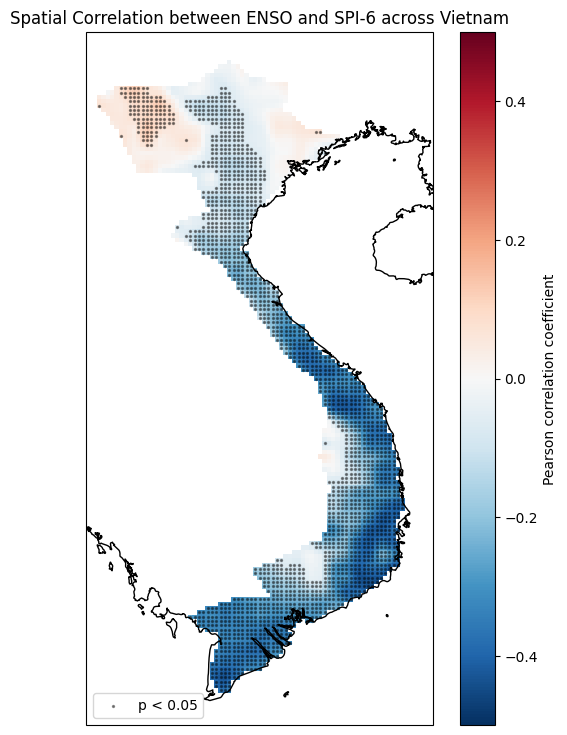

In [63]:
# Sort spatial coordinates before plotting
correlation_map_plot = correlation_map.sortby(
    ["latitude", "longitude"]
)

pvalue_map_plot = pvalue_map.sortby(
    ["latitude", "longitude"]
)

# Plot spatial ENSO-SPI-6 correlation over Vietnam
fig = plt.figure(figsize=(7, 9))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

correlation_map_plot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5,
    cbar_kwargs={
        "label": "Pearson correlation coefficient"
    }
)

# Identify statistically significant grid cells
significant = (
    pvalue_map_plot < 0.05
)

# Create longitude-latitude grid
lon2d, lat2d = np.meshgrid(
    correlation_map_plot.longitude.values,
    correlation_map_plot.latitude.values
)

# Mark statistically significant grid cells
ax.scatter(
    lon2d[significant.values],
    lat2d[significant.values],
    s=2,
    color="black",
    alpha=0.4,
    transform=ccrs.PlateCarree(),
    label="p < 0.05"
)

ax.coastlines()

ax.set_extent(
    [102, 110, 8, 24],
    crs=ccrs.PlateCarree()
)

ax.legend(
    loc="lower left"
)

plt.title(
    "Spatial Correlation between ENSO and SPI-6 across Vietnam"
)

plt.show()

## 10: ENSO and precipitation conditions in 2025

The previous sections establish the historical relationship between ENSO and precipitation variability across Vietnam.

This section examines whether the unusually wet conditions observed in 2025 are consistent with that historical relationship. The standardized Niño 3.4 index is compared with regional SPI-6 conditions throughout 2025, with particular attention to central and southern Vietnam where the historical ENSO–SPI relationship is strongest.

### 10a: ENSO conditions in 2025

The standardized Niño 3.4 index is examined month by month to identify whether 2025 was characterized by relatively warm or cool tropical Pacific conditions.

Negative values indicate cooler-than-normal Niño 3.4 conditions, while positive values indicate warmer-than-normal conditions.

In [64]:
# Extract standardized Niño 3.4 conditions in 2025
enso_2025 = Enso_34_aligned.sel(
    time=slice("2025-01-01", "2025-12-31")
).to_series()

# Create a clean monthly table
enso_2025_table = pd.DataFrame({
    "Month": enso_2025.index.strftime("%B"),
    "ENSO index": enso_2025.values
})

enso_2025_table["ENSO index"] = (
    enso_2025_table["ENSO index"].round(2)
)

enso_2025_table

,Month,ENSO index
0,January,-0.47
1,February,-0.07
2,March,0.45
3,April,0.36
4,May,0.31
5,June,0.44
6,July,0.35
7,August,0.09
8,September,-0.04
9,October,0.01


### 10b: Regional SPI-6 conditions in 2025

Regional SPI-6 values are examined throughout 2025 to identify when and where persistent wet or dry conditions occurred.

The monthly SPI-6 patterns are compared with the ENSO conditions identified above. This allows the 2025 rainfall anomaly to be assessed against the historical negative ENSO–SPI relationship found across much of central and southern Vietnam.

In [65]:
# Extract regional SPI-6 values for 2025
spi6_2025 = {}

for region, spi in regional_spi[6].items():

    spi6_2025[region] = spi.loc[
        "2025-01-01":"2025-12-31"
    ]

# Create a monthly table
spi6_2025_table = pd.DataFrame(
    spi6_2025
)

spi6_2025_table.index = (
    spi6_2025_table.index.strftime("%B")
)

spi6_2025_table.index.name = "Month"

spi6_2025_table = spi6_2025_table.round(2)

spi6_2025_table

,Northern Mountains,Red River Delta,North Central Vietnam,South Central Vietnam,Central Highlands,Southern Vietnam
Month,,,,,,
January,0.47,0.60,0.38,0.49,0.76,0.94
February,0.56,1.17,1.10,0.85,1.07,1.14
March,-2.18,-1.59,0.45,0.80,0.68,0.77
April,-1.81,-1.06,0.65,0.83,0.23,0.52
May,-0.93,-0.48,0.51,1.21,0.99,1.17
June,-0.11,0.00,1.03,0.89,0.87,0.77
July,0.45,0.56,1.74,0.88,0.78,0.38
August,0.40,0.77,2.12,0.74,0.64,0.13
September,0.98,1.11,2.41,1.16,1.29,0.31


### 10c: Lag sensitivity of the ENSO–SPI-6 relationship

Because precipitation conditions may respond to ENSO with some delay, a sensitivity analysis is performed using lagged ENSO values.

The analysis focuses on the four regions where the historical ENSO–SPI relationship is strongest. Correlations are tested at lag 0, 1, 3, and 6 months, where a positive lag means that ENSO leads SPI-6 by the specified number of months.

This test assesses whether the ENSO–SPI-6 relationship becomes stronger when delayed responses are considered.

In [66]:
# Test lagged ENSO-SPI-6 correlations

selected_regions = [
    "North Central Vietnam",
    "South Central Vietnam",
    "Central Highlands",
    "Southern Vietnam"
]

lags = [0, 1, 3, 6]

lag_spi6_results = []

for region in selected_regions:

    spi = regional_spi[6][region]

    spi_xr = xr.DataArray(
        spi.values,
        coords={"time": spi.index},
        dims=["time"]
    )

    for lag in lags:

        # Positive lag means ENSO leads SPI-6
        enso_lagged = Enso_34_aligned.shift(
            time=lag
        )

        spi_aligned, enso_aligned = xr.align(
            spi_xr,
            enso_lagged,
            join="inner"
        )

        valid = (
            np.isfinite(spi_aligned.values)
            & np.isfinite(enso_aligned.values)
        )

        spi_values = spi_aligned.values[valid]
        enso_values = enso_aligned.values[valid]

        r, p = stats.pearsonr(
            enso_values,
            spi_values
        )

        decision = (
            "Reject H0"
            if p < 0.05
            else "Do not reject H0"
        )

        lag_spi6_results.append({
            "Region": region,
            "Lag (months)": lag,
            "Correlation": r,
            "p-value": p,
            "Decision": decision
        })

lag_spi6_results = pd.DataFrame(
    lag_spi6_results
)

lag_spi6_results

,Region,Lag (months),Correlation,p-value,Decision
0,North Central Vietnam,0,-0.252707,1.110754e-14,Reject H0
1,North Central Vietnam,1,-0.278269,1.364407e-17,Reject H0
2,North Central Vietnam,3,-0.307022,2.987739e-21,Reject H0
3,North Central Vietnam,6,-0.264737,5.382033e-16,Reject H0
4,South Central Vietnam,0,-0.391691,1.250973e-34,Reject H0
5,South Central Vietnam,1,-0.416386,2.417426e-39,Reject H0
6,South Central Vietnam,3,-0.426026,2.712157e-41,Reject H0
7,South Central Vietnam,6,-0.318033,9.655110e-23,Reject H0
8,Central Highlands,0,-0.229512,2.631157e-12,Reject H0
9,Central Highlands,1,-0.268539,1.905601e-16,Reject H0


### 10d: Was 2025 consistent with the historical ENSO–rainfall relationship?

The historical ENSO–rainfall relationship is used as an empirical benchmark for evaluating rainfall conditions in 2025. The analysis first constructs monthly regional precipitation anomalies, then estimates the historical ENSO–rainfall relationship over 1950–2024, and finally compares observed rainfall in 2025 with the rainfall anomalies implied by that historical relationship.

In [73]:
regions_order = [
    "Northern Mountains",
    "Red River Delta",
    "North Central Vietnam",
    "South Central Vietnam",
    "Central Highlands",
    "Southern Vietnam"
]

lat_weights = np.cos(
    np.deg2rad(precip["latitude"])
)

lat_weights = xr.DataArray(
    lat_weights,
    coords={"latitude": precip["latitude"]},
    dims=["latitude"]
)

regional_anomalies = {}

for region in regions_order:

    regional_precip = (
        precip
        .where(region_masks[region])
        .weighted(lat_weights)
        .mean(
            dim=("latitude", "longitude")
        )
    )

    climatology = (
        regional_precip
        .sel(
            valid_time=slice(
                "1950-01-01",
                "2024-12-31"
            )
        )
        .groupby("valid_time.month")
        .mean("valid_time")
    )

    rainfall_anomaly = (
        regional_precip.groupby("valid_time.month")
        - climatology
    )

    regional_anomalies[region] = rainfall_anomaly.rename(
        {"valid_time": "time"}
    )

For each region, monthly precipitation anomalies are aligned with the standardized Niño 3.4 index. A simple linear regression is then estimated over 1950–2024 to describe the historical association between ENSO and monthly rainfall anomalies.

In [74]:
historical_models = {}
historical_model_results = []

for region in regions_order:

    rainfall_aligned, enso_aligned = xr.align(
        regional_anomalies[region],
        Enso_34_aligned,
        join="inner"
    )

    df_region = pd.DataFrame(
        {
            "Rainfall_anomaly": rainfall_aligned.values,
            "ENSO": enso_aligned.values
        },
        index=pd.to_datetime(
            rainfall_aligned.time.values
        )
    ).dropna()

    historical = df_region.loc[
        "1950-01-01":"2024-12-31"
    ].copy()

    X_hist = sm.add_constant(
        historical["ENSO"]
    )

    model = sm.OLS(
        historical["Rainfall_anomaly"],
        X_hist
    ).fit()

    historical_models[region] = {
        "model": model,
        "data": df_region
    }

    historical_model_results.append(
        {
            "Region": region,
            "Beta": model.params["ENSO"],
            "p-value": model.pvalues["ENSO"],
            "R²": model.rsquared
        }
    )

historical_model_summary = pd.DataFrame(
    historical_model_results
)

historical_model_summary

,Region,Beta,p-value,R²
0,Northern Mountains,0.123917,9.515182e-01,0.000004
1,Red River Delta,-1.594171,5.301793e-01,0.000439
2,North Central Vietnam,-11.614717,8.984313e-06,0.021728
3,South Central Vietnam,-21.153641,1.669478e-15,0.068225
4,Central Highlands,-10.287550,7.761293e-08,0.031650
5,Southern Vietnam,-10.766977,9.519503e-11,0.045631


The historical regression is then applied to ENSO conditions observed in each month of 2025. This produces an expected rainfall anomaly and a 95% prediction interval for each region and month. The observed 2025 anomaly is compared with this historical benchmark.

In [75]:
regional_prediction_tables = {}

for region in regions_order:

    model = historical_models[region]["model"]
    df_region = historical_models[region]["data"]

    data_2025 = df_region.loc[
        "2025-01-01":"2025-12-31"
    ].copy()

    X_2025 = sm.add_constant(
        data_2025["ENSO"],
        has_constant="add"
    )

    prediction = model.get_prediction(
        X_2025
    ).summary_frame(alpha=0.05)

    result_2025 = pd.DataFrame(
        {
            "Month": data_2025.index.strftime("%b"),
            "ENSO": data_2025["ENSO"].values,
            "Observed anomaly [mm]":
                data_2025["Rainfall_anomaly"].values,
            "Expected anomaly [mm]":
                prediction["mean"].values,
            "PI lower [mm]":
                prediction["obs_ci_lower"].values,
            "PI upper [mm]":
                prediction["obs_ci_upper"].values
        },
        index=data_2025.index
    )

    result_2025["Within 95% PI"] = (
        (
            result_2025["Observed anomaly [mm]"]
            >= result_2025["PI lower [mm]"]
        )
        &
        (
            result_2025["Observed anomaly [mm]"]
            <= result_2025["PI upper [mm]"]
        )
    )

    result_2025["Residual [mm]"] = (
        result_2025["Observed anomaly [mm]"]
        - result_2025["Expected anomaly [mm]"]
    )

    regional_prediction_tables[region] = result_2025

The final comparison summarizes how many months in each region fall within the historical 95% prediction interval and highlights the monthly results for the central regions where the ENSO–rainfall relationship is strongest.

In [76]:
comparison_summary = []

for region in regions_order:

    result_2025 = regional_prediction_tables[region]

    comparison_summary.append(
        {
            "Region": region,
            "Months within 95% PI":
                int(result_2025["Within 95% PI"].sum()),
            "Total months":
                len(result_2025)
        }
    )

comparison_summary = pd.DataFrame(
    comparison_summary
)

comparison_summary

,Region,Months within 95% PI,Total months
0,Northern Mountains,12,12
1,Red River Delta,12,12
2,North Central Vietnam,11,12
3,South Central Vietnam,11,12
4,Central Highlands,10,12
5,Southern Vietnam,12,12


In [77]:
display(
    regional_prediction_tables[
        "North Central Vietnam"
    ].round(1)
)

display(
    regional_prediction_tables[
        "South Central Vietnam"
    ].round(1)
)

display(
    regional_prediction_tables[
        "Central Highlands"
    ].round(1)
)

,Month,ENSO,Observed anomaly [mm],Expected anomaly [mm],PI lower [mm],PI upper [mm],Within 95% PI,Residual [mm]
2025-01-01,Jan,-0.5,-18.4,8.7,-141.1,158.4,True,-27.0
2025-02-01,Feb,-0.1,42.9,4.0,-145.7,153.7,True,38.9
2025-03-01,Mar,0.5,-10.4,-2.0,-151.7,147.7,True,-8.4
2025-04-01,Apr,0.4,-3.6,-1.0,-150.7,148.7,True,-2.6
2025-05-01,May,0.3,38.5,-0.4,-150.1,149.3,True,38.9
2025-06-01,Jun,0.4,90.2,-1.9,-151.6,147.8,True,92.0
2025-07-01,Jul,0.4,146.5,-0.9,-150.6,148.8,True,147.4
2025-08-01,Aug,0.1,189.0,2.1,-147.6,151.8,False,186.9
2025-09-01,Sep,-0.0,106.8,3.7,-146.0,153.4,True,103.2
2025-10-01,Oct,0.0,24.6,3.1,-146.6,152.8,True,21.5


,Month,ENSO,Observed anomaly [mm],Expected anomaly [mm],PI lower [mm],PI upper [mm],Within 95% PI,Residual [mm]
2025-01-01,Jan,-0.5,-17.9,15.8,-134.4,166.0,True,-33.7
2025-02-01,Feb,-0.1,75.9,7.3,-142.9,157.5,True,68.6
2025-03-01,Mar,0.5,13.8,-3.7,-153.8,146.5,True,17.4
2025-04-01,Apr,0.4,-45.7,-1.7,-151.9,148.4,True,-44.0
2025-05-01,May,0.3,25.2,-0.7,-150.9,149.4,True,26.0
2025-06-01,Jun,0.4,73.7,-3.4,-153.6,146.7,True,77.1
2025-07-01,Jul,0.4,-22.5,-1.6,-151.8,148.5,True,-20.9
2025-08-01,Aug,0.1,53.2,3.9,-146.3,154.0,True,49.3
2025-09-01,Sep,-0.0,93.1,6.7,-143.5,156.8,True,86.4
2025-10-01,Oct,0.0,73.3,5.6,-144.5,155.8,True,67.7


,Month,ENSO,Observed anomaly [mm],Expected anomaly [mm],PI lower [mm],PI upper [mm],Within 95% PI,Residual [mm]
2025-01-01,Jan,-0.5,-10.5,7.7,-101.7,117.0,True,-18.2
2025-02-01,Feb,-0.1,18.8,3.5,-105.8,112.9,True,15.3
2025-03-01,Mar,0.5,-17.7,-1.8,-111.1,107.5,True,-15.9
2025-04-01,Apr,0.4,-40.6,-0.8,-110.1,108.5,True,-39.8
2025-05-01,May,0.3,85.0,-0.3,-109.6,109.0,True,85.3
2025-06-01,Jun,0.4,68.8,-1.7,-111.0,107.6,True,70.5
2025-07-01,Jul,0.4,-7.4,-0.8,-110.1,108.5,True,-6.7
2025-08-01,Aug,0.1,6.9,1.9,-107.4,111.2,True,5.0
2025-09-01,Sep,-0.0,119.3,3.2,-106.1,112.6,False,116.1
2025-10-01,Oct,0.0,22.4,2.7,-106.6,112.1,True,19.7


### 10e: Comparing 2025 with the historical ENSO–SPI relationship

Monthly rainfall contains substantial short-term variability, while the historical analysis shows that the ENSO relationship becomes clearer when precipitation is accumulated over several months. The 2025 comparison is therefore repeated using SPI-3 and SPI-6.

For each region, accumulated precipitation is transformed into SPI using Gamma distributions fitted to the 1950–2024 reference period separately for each calendar month. Historical regressions of SPI on the standardized Niño 3.4 index are then estimated over 1950–2024. The fitted relationships are applied to ENSO conditions in 2025 to obtain expected SPI values and 95% prediction intervals.

In [78]:
regions_order = [
    "Northern Mountains",
    "Red River Delta",
    "North Central Vietnam",
    "South Central Vietnam",
    "Central Highlands",
    "Southern Vietnam"
]

lat_weights = xr.DataArray(
    np.cos(np.deg2rad(precip["latitude"])),
    coords={"latitude": precip["latitude"]},
    dims=["latitude"]
)

regional_precip_series = {}

for region in regions_order:

    regional_precip_series[region] = (
        precip
        .where(region_masks[region])
        .weighted(lat_weights)
        .mean(dim=("latitude", "longitude"))
        .sel(valid_time=slice("1950-01-01", "2025-12-31"))
        .to_series()
        .dropna()
    )

SPI-3 and SPI-6 are calculated using a fixed historical reference period. For each calendar month, the Gamma distribution is estimated from accumulated precipitation during 1950–2024 and then applied to both the historical observations and 2025.

In [79]:
def calculate_spi_with_reference(
    rainfall,
    accumulation,
    reference_end="2024-12-31"
):

    accumulated = rainfall.rolling(
        window=accumulation,
        min_periods=accumulation
    ).sum()

    spi = pd.Series(
        np.nan,
        index=accumulated.index,
        dtype=float
    )

    for month in range(1, 13):

        month_data = accumulated[
            accumulated.index.month == month
        ].dropna()

        historical = month_data.loc[
            :"2024-12-31"
        ]

        positive_hist = historical[
            historical > 0
        ]

        if len(positive_hist) == 0:
            continue

        zero_probability = (
            (historical == 0).sum()
            / len(historical)
        )

        shape, loc, scale = stats.gamma.fit(
            positive_hist.values,
            floc=0
        )

        values = month_data.values

        gamma_probability = stats.gamma.cdf(
            np.maximum(values, 0),
            shape,
            loc=0,
            scale=scale
        )

        probability = (
            zero_probability
            + (1 - zero_probability)
            * gamma_probability
        )

        probability = np.clip(
            probability,
            1e-6,
            1 - 1e-6
        )

        spi_values = stats.norm.ppf(
            probability
        )

        spi_values = np.clip(
            spi_values,
            -3,
            3
        )

        spi.loc[month_data.index] = spi_values

    return spi

In [80]:
regional_spi = {
    3: {},
    6: {}
}

for accumulation in [3, 6]:

    for region in regions_order:

        regional_spi[accumulation][region] = (
            calculate_spi_with_reference(
                regional_precip_series[region],
                accumulation
            )
        )

The historical relationship is estimated separately for SPI-3 and SPI-6. For each region, SPI is aligned with the standardized Niño 3.4 index and a linear regression is estimated over 1950–2024.

In [82]:
spi_models = {}
spi_model_summary = []

enso_series = pd.Series(
    Enso_34_aligned.values,
    index=pd.to_datetime(
        Enso_34_aligned.time.values
    ),
    name="ENSO"
)

for accumulation in [3, 6]:

    spi_models[accumulation] = {}

    for region in regions_order:

        spi_series = (
            regional_spi[accumulation][region]
            .rename("SPI")
        )

        df = pd.concat(
            [spi_series, enso_series],
            axis=1,
            join="inner"
        ).dropna()

        historical = df.loc[
            "1950-01-01":"2024-12-31"
        ]

        X = sm.add_constant(
            historical["ENSO"]
        )

        model = sm.OLS(
            historical["SPI"],
            X
        ).fit()

        spi_models[accumulation][region] = {
            "model": model,
            "data": df
        }

        spi_model_summary.append({
            "SPI": f"SPI-{accumulation}",
            "Region": region,
            "Beta": model.params["ENSO"],
            "p-value": model.pvalues["ENSO"],
            "R²": model.rsquared
        })

spi_model_summary = pd.DataFrame(
    spi_model_summary
)

spi_model_summary

,SPI,Region,Beta,p-value,R²
0,SPI-3,Northern Mountains,0.019018,5.663678e-01,0.000367
1,SPI-3,Red River Delta,0.023050,4.987503e-01,0.000511
2,SPI-3,North Central Vietnam,-0.232663,1.850866e-12,0.053920
3,SPI-3,South Central Vietnam,-0.350904,5.369301e-26,0.116768
4,SPI-3,Central Highlands,-0.257523,2.362695e-14,0.062929
5,SPI-3,Southern Vietnam,-0.303342,1.235324e-19,0.087696
6,SPI-6,Northern Mountains,0.008409,7.923119e-01,0.000078
7,SPI-6,Red River Delta,-0.037792,2.644230e-01,0.001394
8,SPI-6,North Central Vietnam,-0.256525,2.332466e-14,0.063160
9,SPI-6,South Central Vietnam,-0.403161,2.828924e-34,0.153780


The fitted historical relationships are applied to the ENSO values observed in 2025. Observed SPI values are compared with the expected SPI and the corresponding 95% prediction intervals.

In [83]:
spi_prediction_tables = {}

for accumulation in [3, 6]:

    spi_prediction_tables[accumulation] = {}

    for region in regions_order:

        model = (
            spi_models[accumulation][region]["model"]
        )

        df = (
            spi_models[accumulation][region]["data"]
        )

        data_2025 = df.loc[
            "2025-01-01":"2025-12-31"
        ].copy()

        X_2025 = sm.add_constant(
            data_2025["ENSO"],
            has_constant="add"
        )

        prediction = model.get_prediction(
            X_2025
        ).summary_frame(alpha=0.05)

        result = pd.DataFrame(
            {
                "Month":
                    data_2025.index.strftime("%b"),
                "ENSO":
                    data_2025["ENSO"].values,
                "Observed SPI":
                    data_2025["SPI"].values,
                "Expected SPI":
                    prediction["mean"].values,
                "PI lower":
                    prediction["obs_ci_lower"].values,
                "PI upper":
                    prediction["obs_ci_upper"].values
            },
            index=data_2025.index
        )

        result["Within 95% PI"] = (
            (result["Observed SPI"]
             >= result["PI lower"])
            &
            (result["Observed SPI"]
             <= result["PI upper"])
        )

        result["Residual"] = (
            result["Observed SPI"]
            - result["Expected SPI"]
        )

        spi_prediction_tables[
            accumulation
        ][region] = result

The number of 2025 observations falling within and outside the historical prediction interval is summarized for each region and accumulation period.

In [84]:
spi_prediction_summary = []

for accumulation in [3, 6]:

    for region in regions_order:

        result = (
            spi_prediction_tables[
                accumulation
            ][region]
        )

        n_within = int(
            result["Within 95% PI"].sum()
        )

        n_total = len(result)

        spi_prediction_summary.append({
            "SPI": f"SPI-{accumulation}",
            "Region": region,
            "Months within 95% PI": n_within,
            "Months outside 95% PI":
                n_total - n_within
        })

spi_prediction_summary = pd.DataFrame(
    spi_prediction_summary
)

spi_prediction_summary

,SPI,Region,Months within 95% PI,Months outside 95% PI
0,SPI-3,Northern Mountains,12,0
1,SPI-3,Red River Delta,12,0
2,SPI-3,North Central Vietnam,10,2
3,SPI-3,South Central Vietnam,12,0
4,SPI-3,Central Highlands,12,0
5,SPI-3,Southern Vietnam,12,0
6,SPI-6,Northern Mountains,10,2
7,SPI-6,Red River Delta,12,0
8,SPI-6,North Central Vietnam,7,5
9,SPI-6,South Central Vietnam,12,0


In [85]:
for accumulation in [3, 6]:

    print(
        f"\n========== SPI-{accumulation} ==========\n"
    )

    print("North Central Vietnam")
    display(
        spi_prediction_tables[
            accumulation
        ]["North Central Vietnam"].round(2)
    )

    print("South Central Vietnam")
    display(
        spi_prediction_tables[
            accumulation
        ]["South Central Vietnam"].round(2)
    )


========== SPI-3 ==========

North Central Vietnam


,Month,ENSO,Observed SPI,Expected SPI,PI lower,PI upper,Within 95% PI,Residual
2025-01-01,Jan,-0.47,0.60,0.17,-1.70,2.03,True,0.44
2025-02-01,Feb,-0.07,0.60,0.08,-1.79,1.94,True,0.53
2025-03-01,Mar,0.45,0.36,-0.04,-1.91,1.82,True,0.41
2025-04-01,Apr,0.36,0.59,-0.02,-1.89,1.84,True,0.62
2025-05-01,May,0.31,0.36,-0.01,-1.88,1.85,True,0.37
2025-06-01,Jun,0.44,1.12,-0.04,-1.91,1.82,True,1.16
2025-07-01,Jul,0.35,1.81,-0.02,-1.89,1.84,True,1.84
2025-08-01,Aug,0.09,2.58,0.04,-1.83,1.90,False,2.54
2025-09-01,Sep,-0.04,2.38,0.07,-1.80,1.93,False,2.31
2025-10-01,Oct,0.01,1.51,0.06,-1.81,1.92,True,1.46


South Central Vietnam


,Month,ENSO,Observed SPI,Expected SPI,PI lower,PI upper,Within 95% PI,Residual
2025-01-01,Jan,-0.47,0.83,0.26,-1.59,2.11,True,0.57
2025-02-01,Feb,-0.07,1.67,0.12,-1.73,1.97,True,1.55
2025-03-01,Mar,0.45,1.04,-0.06,-1.91,1.79,True,1.10
2025-04-01,Apr,0.36,0.66,-0.03,-1.88,1.82,True,0.69
2025-05-01,May,0.31,0.03,-0.01,-1.86,1.84,True,0.04
2025-06-01,Jun,0.44,0.58,-0.06,-1.90,1.79,True,0.63
2025-07-01,Jul,0.35,0.83,-0.03,-1.87,1.82,True,0.86
2025-08-01,Aug,0.09,1.26,0.07,-1.78,1.91,True,1.19
2025-09-01,Sep,-0.04,1.18,0.11,-1.74,1.96,True,1.07
2025-10-01,Oct,0.01,1.50,0.09,-1.75,1.94,True,1.41



========== SPI-6 ==========

North Central Vietnam


,Month,ENSO,Observed SPI,Expected SPI,PI lower,PI upper,Within 95% PI,Residual
2025-01-01,Jan,-0.47,0.38,0.19,-1.69,2.08,True,0.19
2025-02-01,Feb,-0.07,1.12,0.09,-1.79,1.98,True,1.03
2025-03-01,Mar,0.45,0.46,-0.04,-1.93,1.85,True,0.50
2025-04-01,Apr,0.36,0.66,-0.02,-1.90,1.87,True,0.67
2025-05-01,May,0.31,0.52,-0.00,-1.89,1.88,True,0.52
2025-06-01,Jun,0.44,1.04,-0.04,-1.92,1.85,True,1.08
2025-07-01,Jul,0.35,1.79,-0.02,-1.90,1.87,True,1.80
2025-08-01,Aug,0.09,2.21,0.05,-1.84,1.94,False,2.15
2025-09-01,Sep,-0.04,2.52,0.08,-1.80,1.97,False,2.44
2025-10-01,Oct,0.01,2.23,0.07,-1.81,1.96,False,2.16


South Central Vietnam


,Month,ENSO,Observed SPI,Expected SPI,PI lower,PI upper,Within 95% PI,Residual
2025-01-01,Jan,-0.47,0.49,0.30,-1.50,2.11,True,0.19
2025-02-01,Feb,-0.07,0.86,0.14,-1.66,1.95,True,0.72
2025-03-01,Mar,0.45,0.81,-0.07,-1.87,1.74,True,0.88
2025-04-01,Apr,0.36,0.84,-0.03,-1.84,1.78,True,0.87
2025-05-01,May,0.31,1.23,-0.01,-1.82,1.80,True,1.24
2025-06-01,Jun,0.44,0.90,-0.06,-1.87,1.74,True,0.96
2025-07-01,Jul,0.35,0.89,-0.03,-1.83,1.78,True,0.92
2025-08-01,Aug,0.09,0.75,0.08,-1.73,1.88,True,0.67
2025-09-01,Sep,-0.04,1.18,0.13,-1.68,1.94,True,1.05
2025-10-01,Oct,0.01,1.61,0.11,-1.69,1.92,True,1.50


### 10f: Moving block bootstrap for the 2025 ENSO–SPI-3 and SPI-6 comparison

Because SPI-3 and SPI-6 are calculated from overlapping precipitation windows, consecutive observations are not independent. A moving block bootstrap is therefore used to preserve the short-term temporal dependence in the historical residual series.

For each region and SPI accumulation period, historical residuals are calculated as the difference between observed SPI and the SPI expected from the historical ENSO regression. Blocks of consecutive residuals are then resampled with replacement to generate synthetic 12-month episodes.

The observed mean residual in 2025 is compared with the bootstrap distribution. A positive residual indicates wetter conditions than expected from the historical ENSO relationship, while a negative residual indicates drier conditions.

In [86]:
bootstrap_inputs = {}

for accumulation in [3, 6]:

    bootstrap_inputs[accumulation] = {}

    for region in regions_order:

        model = spi_models[accumulation][region]["model"]
        df = spi_models[accumulation][region]["data"].copy()

        historical = df.loc[
            "1950-01-01":"2024-12-31"
        ].copy()

        data_2025 = df.loc[
            "2025-01-01":"2025-12-31"
        ].copy()

        historical_X = sm.add_constant(
            historical["ENSO"],
            has_constant="add"
        )

        data_2025_X = sm.add_constant(
            data_2025["ENSO"],
            has_constant="add"
        )

        historical["Expected_SPI"] = model.predict(
            historical_X
        )

        data_2025["Expected_SPI"] = model.predict(
            data_2025_X
        )

        historical["Residual"] = (
            historical["SPI"]
            - historical["Expected_SPI"]
        )

        data_2025["Residual"] = (
            data_2025["SPI"]
            - data_2025["Expected_SPI"]
        )

        bootstrap_inputs[accumulation][region] = {
            "historical": historical,
            "2025": data_2025
        }

The block length is set equal to the SPI accumulation period. This preserves the temporal dependence introduced by the overlapping precipitation windows while allowing synthetic 12-month episodes to be generated from the historical residual series.

In [87]:
def moving_block_bootstrap(
    residuals,
    block_length,
    episode_length=12,
    n_bootstrap=10000,
    seed=42
):

    residuals = np.asarray(residuals)
    residuals = residuals[np.isfinite(residuals)]

    rng = np.random.default_rng(seed)

    n = len(residuals)

    blocks = np.array([
        residuals[i:i + block_length]
        for i in range(
            n - block_length + 1
        )
    ])

    bootstrap_means = np.empty(
        n_bootstrap
    )

    n_blocks_needed = int(
        np.ceil(
            episode_length / block_length
        )
    )

    for b in range(n_bootstrap):

        selected = rng.integers(
            0,
            len(blocks),
            size=n_blocks_needed
        )

        synthetic_episode = np.concatenate(
            blocks[selected]
        )[:episode_length]

        bootstrap_means[b] = (
            synthetic_episode.mean()
        )

    return bootstrap_means

In [88]:
bootstrap_results = []
bootstrap_distributions = {}

for accumulation in [3, 6]:

    bootstrap_distributions[accumulation] = {}

    block_length = accumulation

    for region in regions_order:

        historical = (
            bootstrap_inputs[
                accumulation
            ][region]["historical"]
        )

        data_2025 = (
            bootstrap_inputs[
                accumulation
            ][region]["2025"]
        )

        historical_residuals = (
            historical["Residual"]
            .dropna()
            .values
        )

        observed_2025 = (
            data_2025["Residual"]
            .mean()
        )

        boot = moving_block_bootstrap(
            historical_residuals,
            block_length=block_length,
            episode_length=12,
            n_bootstrap=10000,
            seed=42
        )

        bootstrap_distributions[
            accumulation
        ][region] = boot

        lower = np.percentile(
            boot,
            2.5
        )

        upper = np.percentile(
            boot,
            97.5
        )

        p_wet = (
            np.sum(
                boot >= observed_2025
            ) + 1
        ) / (
            len(boot) + 1
        )

        p_two_sided = (
            np.sum(
                np.abs(boot)
                >= np.abs(observed_2025)
            ) + 1
        ) / (
            len(boot) + 1
        )

        bootstrap_results.append({
            "SPI": f"SPI-{accumulation}",
            "Region": region,
            "2025 mean residual":
                observed_2025,
            "Bootstrap 2.5%":
                lower,
            "Bootstrap 97.5%":
                upper,
            "Wet-tail p-value":
                p_wet,
            "Two-sided p-value":
                p_two_sided,
            "Outside 95% range":
                (
                    observed_2025 < lower
                    or observed_2025 > upper
                )
        })

bootstrap_summary = pd.DataFrame(
    bootstrap_results
)

bootstrap_summary

,SPI,Region,2025 mean residual,Bootstrap 2.5%,Bootstrap 97.5%,Wet-tail p-value,Two-sided p-value,Outside 95% range
0,SPI-3,Northern Mountains,0.049017,-0.833642,0.827939,0.464954,0.901810,False
1,SPI-3,Red River Delta,0.125133,-0.834748,0.829845,0.388161,0.759624,False
2,SPI-3,North Central Vietnam,1.097270,-0.791479,0.800965,0.003900,0.007799,True
3,SPI-3,South Central Vietnam,0.938794,-0.779755,0.806350,0.012399,0.019698,True
4,SPI-3,Central Highlands,0.815707,-0.819226,0.844874,0.029397,0.054895,False
5,SPI-3,Southern Vietnam,0.339151,-0.850190,0.827732,0.220978,0.441756,False
6,SPI-6,Northern Mountains,0.110170,-1.231630,1.062042,0.434957,0.831517,False
7,SPI-6,Red River Delta,0.366480,-1.198549,1.180070,0.267973,0.532147,False
8,SPI-6,North Central Vietnam,1.386351,-1.162753,1.204481,0.013799,0.025797,True
9,SPI-6,South Central Vietnam,0.969398,-1.044951,1.100380,0.043196,0.079292,False


In [89]:
bootstrap_summary_display = (
    bootstrap_summary.copy()
)

bootstrap_summary_display[
    "2025 mean residual"
] = bootstrap_summary_display[
    "2025 mean residual"
].round(2)

bootstrap_summary_display[
    "Bootstrap 2.5%"
] = bootstrap_summary_display[
    "Bootstrap 2.5%"
].round(2)

bootstrap_summary_display[
    "Bootstrap 97.5%"
] = bootstrap_summary_display[
    "Bootstrap 97.5%"
].round(2)

bootstrap_summary_display[
    "Wet-tail p-value"
] = bootstrap_summary_display[
    "Wet-tail p-value"
].round(4)

bootstrap_summary_display[
    "Two-sided p-value"
] = bootstrap_summary_display[
    "Two-sided p-value"
].round(4)

bootstrap_summary_display

,SPI,Region,2025 mean residual,Bootstrap 2.5%,Bootstrap 97.5%,Wet-tail p-value,Two-sided p-value,Outside 95% range
0,SPI-3,Northern Mountains,0.05,-0.83,0.83,0.4650,0.9018,False
1,SPI-3,Red River Delta,0.13,-0.83,0.83,0.3882,0.7596,False
2,SPI-3,North Central Vietnam,1.10,-0.79,0.80,0.0039,0.0078,True
3,SPI-3,South Central Vietnam,0.94,-0.78,0.81,0.0124,0.0197,True
4,SPI-3,Central Highlands,0.82,-0.82,0.84,0.0294,0.0549,False
5,SPI-3,Southern Vietnam,0.34,-0.85,0.83,0.2210,0.4418,False
6,SPI-6,Northern Mountains,0.11,-1.23,1.06,0.4350,0.8315,False
7,SPI-6,Red River Delta,0.37,-1.20,1.18,0.2680,0.5321,False
8,SPI-6,North Central Vietnam,1.39,-1.16,1.20,0.0138,0.0258,True
9,SPI-6,South Central Vietnam,0.97,-1.04,1.10,0.0432,0.0793,False


In [90]:
bootstrap_summary_display[
    bootstrap_summary_display["Region"].isin(
        [
            "North Central Vietnam",
            "South Central Vietnam"
        ]
    )
]

,SPI,Region,2025 mean residual,Bootstrap 2.5%,Bootstrap 97.5%,Wet-tail p-value,Two-sided p-value,Outside 95% range
2,SPI-3,North Central Vietnam,1.10,-0.79,0.80,0.0039,0.0078,True
3,SPI-3,South Central Vietnam,0.94,-0.78,0.81,0.0124,0.0197,True
8,SPI-6,North Central Vietnam,1.39,-1.16,1.20,0.0138,0.0258,True
9,SPI-6,South Central Vietnam,0.97,-1.04,1.10,0.0432,0.0793,False


The autocorrelation of historical regression residuals is also examined to assess the persistence retained by the block bootstrap.

In [91]:
from statsmodels.tsa.stattools import acf

acf_results = []

for accumulation in [3, 6]:

    for region in regions_order:

        residuals = (
            bootstrap_inputs[
                accumulation
            ][region]["historical"]["Residual"]
            .dropna()
        )

        residual_acf = acf(
            residuals,
            nlags=12,
            fft=True
        )

        acf_results.append({
            "SPI": f"SPI-{accumulation}",
            "Region": region,
            "Lag 1": residual_acf[1],
            "Lag 2": residual_acf[2],
            "Lag 3": residual_acf[3],
            "Lag 6": residual_acf[6],
            "Lag 12": residual_acf[12]
        })

acf_summary = pd.DataFrame(
    acf_results
)

acf_summary.round(3)

,SPI,Region,Lag 1,Lag 2,Lag 3,Lag 6,Lag 12
0,SPI-3,Northern Mountains,0.716,0.414,0.150,0.194,0.126
1,SPI-3,Red River Delta,0.699,0.406,0.158,0.167,0.104
2,SPI-3,North Central Vietnam,0.668,0.423,0.166,0.181,0.068
3,SPI-3,South Central Vietnam,0.684,0.417,0.156,0.089,0.113
4,SPI-3,Central Highlands,0.730,0.500,0.234,0.088,0.177
5,SPI-3,Southern Vietnam,0.775,0.531,0.253,0.100,0.115
6,SPI-6,Northern Mountains,0.861,0.724,0.614,0.262,0.208
7,SPI-6,Red River Delta,0.843,0.703,0.598,0.255,0.199
8,SPI-6,North Central Vietnam,0.828,0.712,0.606,0.228,0.117
9,SPI-6,South Central Vietnam,0.860,0.717,0.568,0.150,0.127


## 11: Hue case study — rainfall conditions in 2025

The Vietnam-wide analysis identified particularly wet conditions across Central Vietnam during 2025.

This section focuses on Hue to examine how rainfall evolved throughout the year and identify the month with the largest positive rainfall anomaly. Monthly rainfall is compared with the corresponding historical monthly climatology, allowing seasonal differences in rainfall to be taken into account before examining the most unusual wet month in greater detail.

### 11a: Monthly precipitation in Hue during 2025

Hue is examined separately to assess monthly rainfall conditions throughout 2025.

The administrative boundary is extracted from Natural Earth and used to calculate an area-weighted monthly precipitation series.

In [93]:
# Extract Hue boundary from Natural Earth admin-1 data

admin1_shp = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_1_states_provinces"
)

admin1_reader = shpreader.Reader(admin1_shp)

hue_geometry = None

for record in admin1_reader.records():

    name = record.attributes.get("name")

    if name == "Thừa Thiên - Huế":
        hue_geometry = record.geometry
        break

if hue_geometry is None:
    raise ValueError("Hue was not found.")

# Create Hue mask on the ERA5-Land grid
lon2d, lat2d = np.meshgrid(
    precip.longitude.values,
    precip.latitude.values
)

hue_mask = contains_xy(
    hue_geometry,
    lon2d,
    lat2d
)

hue_mask = xr.DataArray(
    hue_mask,
    coords={
        "latitude": precip.latitude,
        "longitude": precip.longitude
    },
    dims=("latitude", "longitude")
)

print(
    "Hue grid cells:",
    int(hue_mask.sum())
)

Hue grid cells: 40


In [94]:
# Calculate area-weighted monthly rainfall over Hue

lat_weights_hue = np.cos(
    np.deg2rad(precip["latitude"])
)

lat_weights_hue = xr.DataArray(
    lat_weights_hue,
    coords={"latitude": precip["latitude"]},
    dims=["latitude"]
)

hue_monthly = (
    precip.where(hue_mask)
    .weighted(lat_weights_hue)
    .mean(dim=("latitude", "longitude"))
)

print(
    "Valid monthly observations:",
    int(hue_monthly.notnull().sum())
)

Valid monthly observations: 920


### 11b: Rainfall anomalies in Hue during 2025

Monthly rainfall in 2025 is compared with the corresponding historical monthly climatology over 1950–2024.

Because each month is compared with the same calendar month in the historical record, the seasonal rainfall cycle is accounted for. Absolute and percentage anomalies are calculated to identify the month with the largest positive rainfall anomaly.

In [95]:
# Historical monthly climatology: 1950–2024

hue_climatology = (
    hue_monthly
    .sel(valid_time=slice("1950-01-01", "2024-12-31"))
    .groupby("valid_time.month")
    .mean(dim="valid_time")
)

# Monthly rainfall in 2025
hue_2025 = hue_monthly.sel(
    valid_time=slice("2025-01-01", "2025-12-31")
)

results = []

for date, rainfall in zip(
    hue_2025.valid_time.values,
    hue_2025.values
):

    timestamp = pd.Timestamp(date)
    month = timestamp.month
    month_name = timestamp.strftime("%B")

    climatology = float(
        hue_climatology.sel(month=month)
    )

    anomaly = float(rainfall) - climatology

    anomaly_percent = (
        anomaly / climatology
    ) * 100

    results.append({
        "Month": month_name,
        "Rainfall 2025 [mm]": float(rainfall),
        "Climatology 1950–2024 [mm]": climatology,
        "Anomaly [mm]": anomaly,
        "Anomaly [%]": anomaly_percent
    })

hue_2025_summary = pd.DataFrame(results)

hue_2025_summary = hue_2025_summary.round(1)

hue_2025_summary

,Month,Rainfall 2025 [mm],Climatology 1950–2024 [mm],Anomaly [mm],Anomaly [%]
0,January,147.9,173.0,-25.1,-14.5
1,February,192.5,110.1,82.4,74.8
2,March,147.4,125.8,21.6,17.1
3,April,127.1,157.5,-30.4,-19.3
4,May,296.8,270.9,25.9,9.6
5,June,454.5,197.3,257.1,130.3
6,July,154.6,173.2,-18.6,-10.7
7,August,376.4,209.7,166.7,79.5
8,September,423.6,354.1,69.5,19.6
9,October,931.9,467.7,464.2,99.2


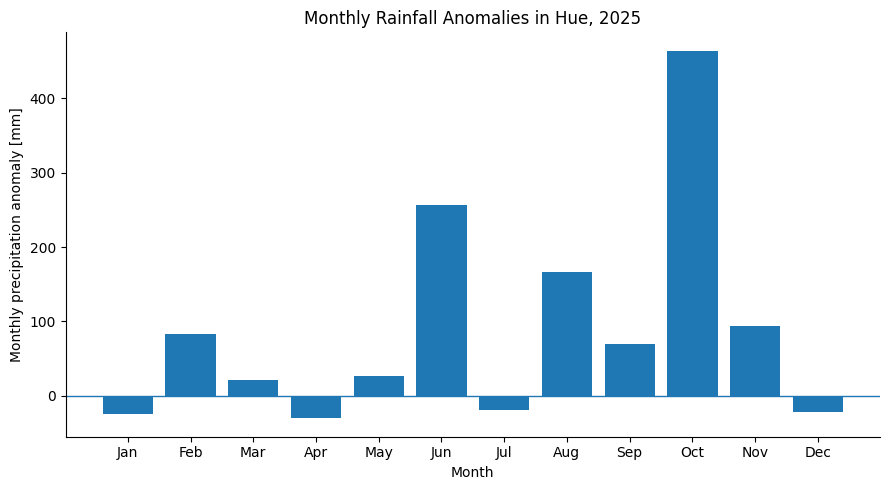

In [97]:
# Monthly rainfall anomalies in Hue during 2025

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    hue_2025_summary["Month"].str[:3],
    hue_2025_summary["Anomaly [mm]"]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel("Month")
ax.set_ylabel("Monthly precipitation anomaly [mm]")

ax.set_title(
    "Monthly Rainfall Anomalies in Hue, 2025"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 11c: Historical context and distribution of October 2025 rainfall

October 2025 rainfall is compared with historical October rainfall in Hue from 1950 to 2024.

Its rarity is assessed using the historical percentile, rank, and empirical return period, while the historical distribution shows where October 2025 lies relative to previous October conditions.

In [99]:
# Extract historical October rainfall in Hue

historical_october = (
    hue_monthly
    .sel(valid_time=slice("1950-01-01", "2024-12-31"))
    .where(
        hue_monthly
        .sel(valid_time=slice("1950-01-01", "2024-12-31"))
        ["valid_time"].dt.month == 10,
        drop=True
    )
    .to_series()
    .dropna()
)

# October 2025 rainfall
october_2025 = float(
    hue_monthly.sel(valid_time="2025-10-01")
)

# Historical October mean
historical_october_mean = historical_october.mean()

# Historical percentile
october_percentile = (
    stats.percentileofscore(
        historical_october.values,
        october_2025,
        kind="rank"
    )
)

# Add October 2025 to the historical sample
all_octobers = pd.concat([
    historical_october,
    pd.Series(
        [october_2025],
        index=[pd.Timestamp("2025-10-01")]
    )
])

# Rank from wettest to driest
october_rank_wettest = (
    all_octobers.rank(
        ascending=False,
        method="min"
    ).loc[pd.Timestamp("2025-10-01")]
)

# Empirical return period using the Weibull plotting-position formula
# T = (N + 1) / m
# N = total number of observations
# m = rank from wettest to driest
# This is an empirical recurrence interval rather than
# a formal return period estimated from an extreme-value model.
n_october = len(all_octobers)

october_return_period = (
    (n_october + 1) / october_rank_wettest
)

print(
    f"October 2025 rainfall: "
    f"{october_2025:.1f} mm"
)

print(
    f"Historical October mean: "
    f"{historical_october_mean:.1f} mm"
)

print(
    f"Historical percentile: "
    f"{october_percentile:.1f}th percentile"
)

print(
    f"Rank among 1950–2025 Octobers: "
    f"{int(october_rank_wettest)} of {n_october}"
)

print(
    f"Historical October maximum before 2025: "
    f"{historical_october.max():.1f} mm"
)

print(
    f"Empirical return period: "
    f"{october_return_period:.1f} years"
)

October 2025 rainfall: 931.9 mm
Historical October mean: 467.7 mm
Historical percentile: 97.3th percentile
Rank among 1950–2025 Octobers: 3 of 76
Historical October maximum before 2025: 1227.2 mm
Empirical return period: 25.7 years


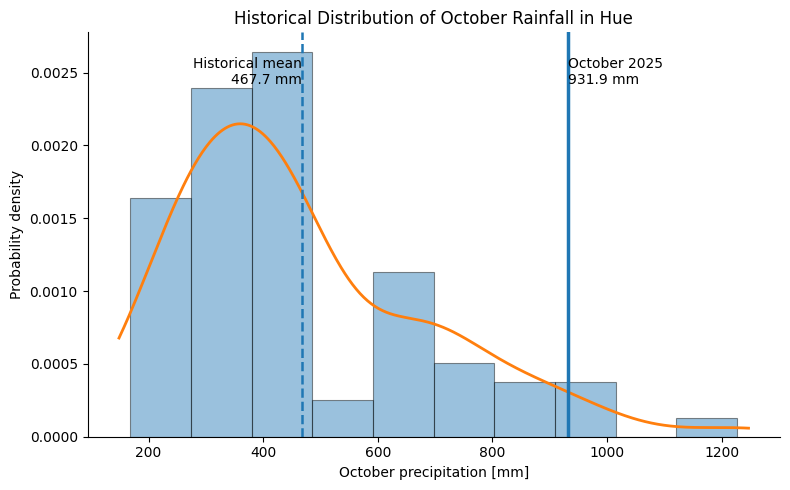

In [100]:
# Historical distribution of October rainfall in Hue

historical_october_values = historical_october.values

fig, ax = plt.subplots(figsize=(8, 5))

# Histogram shown as density so it can be compared with the KDE curve
ax.hist(
    historical_october_values,
    bins=10,
    density=True,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.8
)

# Smooth historical distribution using kernel density estimation
kde = stats.gaussian_kde(
    historical_october_values
)

x_grid = np.linspace(
    historical_october_values.min() - 20,
    historical_october_values.max() + 20,
    500
)

ax.plot(
    x_grid,
    kde(x_grid),
    linewidth=2
)

# Historical October mean
ax.axvline(
    historical_october_mean,
    linestyle="--",
    linewidth=1.8
)

# October 2025 rainfall
ax.axvline(
    october_2025,
    linewidth=2.5
)

# Direct labels
ymax = ax.get_ylim()[1]

ax.text(
    historical_october_mean,
    ymax * 0.94,
    f"Historical mean\n{historical_october_mean:.1f} mm",
    ha="right",
    va="top"
)

ax.text(
    october_2025,
    ymax * 0.94,
    f"October 2025\n{october_2025:.1f} mm",
    ha="left",
    va="top"
)

ax.set_xlabel("October precipitation [mm]")
ax.set_ylabel("Probability density")

ax.set_title(
    "Historical Distribution of October Rainfall in Hue"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 11d: Was October 2025 rainfall consistent with the historical ENSO relationship?

Historical ENSO–rainfall relationships in Hue are compared with the actual Niño 3.4 conditions at 0-, 1-, 3-, and 6-month leads before October 2025.

This comparison assesses whether the exceptionally wet October 2025 was consistent with the historical ENSO signal.

In [109]:
# Historical monthly rainfall climatology: 1950–2024

hue_hist = hue_monthly.sel(
    valid_time=slice("1950-01-01", "2024-12-31")
)

hue_monthly_climatology = (
    hue_hist
    .groupby("valid_time.month")
    .mean("valid_time")
)

# Remove the seasonal rainfall cycle
hue_rainfall_anomaly = (
    hue_hist.groupby("valid_time.month")
    - hue_monthly_climatology
)

# Convert rainfall and ENSO to pandas Series
rainfall_hist_hue = (
    hue_rainfall_anomaly
    .to_series()
    .dropna()
)

enso_hist_hue = (
    Enso_34
    .sel(time=slice("1950-01-01", "2024-12-31"))
    .to_series()
    .dropna()
)

# Align both datasets by calendar month
rainfall_hist_hue.index = (
    rainfall_hist_hue.index.to_period("M")
)

enso_hist_hue.index = (
    enso_hist_hue.index.to_period("M")
)

# Test whether ENSO leads rainfall by 0, 1, 3, or 6 months
lags = [0, 1, 3, 6]

hue_correlation_results = []

for lag in lags:

    # Positive lag means ENSO leads rainfall
    enso_lagged = enso_hist_hue.shift(lag)

    aligned = pd.concat(
        [rainfall_hist_hue, enso_lagged],
        axis=1
    ).dropna()

    r, p = stats.pearsonr(
        aligned.iloc[:, 0],
        aligned.iloc[:, 1]
    )

    hue_correlation_results.append({
        "ENSO lead (months)": lag,
        "Pearson r": r,
        "p-value": p,
        "r² (%)": (r ** 2) * 100
    })

hue_enso_correlation = pd.DataFrame(
    hue_correlation_results
)

# ENSO conditions corresponding to October 2025
reference_dates = {
    0: "2025-10-01",
    1: "2025-09-01",
    3: "2025-07-01",
    6: "2025-04-01"
}

reference_months = {
    0: "October 2025",
    1: "September 2025",
    3: "July 2025",
    6: "April 2025"
}

comparison_results = []

for _, row in hue_enso_correlation.iterrows():

    lag = int(row["ENSO lead (months)"])
    r = float(row["Pearson r"])
    p = float(row["p-value"])

    enso_value = float(
        Enso_34.sel(
            time=reference_dates[lag]
        )
    )

    # Rule-based interpretation
    if abs(enso_value) < 0.1:
        interpretation = "Neutral ENSO"

    elif p >= 0.05:
        interpretation = "Historical relationship not significant"

    elif r < 0 and enso_value < 0:
        interpretation = "Direction consistent with wetter conditions"

    elif r < 0 and enso_value > 0:
        interpretation = "Direction inconsistent with wetter conditions"

    elif r > 0 and enso_value > 0:
        interpretation = "Direction consistent with wetter conditions"

    else:
        interpretation = "Direction inconsistent with wetter conditions"

    comparison_results.append({
        "ENSO lead": f"{lag} month" if lag == 1 else f"{lag} months",
        "Reference month": reference_months[lag],
        "Pearson r": r,
        "p-value": p,
        "r² (%)": (r ** 2) * 100,
        "Niño 3.4": enso_value,
        "Interpretation": interpretation
    })

hue_october_enso_comparison = pd.DataFrame(
    comparison_results
)

# Format for display
hue_october_enso_display = (
    hue_october_enso_comparison.copy()
)

hue_october_enso_display["Pearson r"] = (
    hue_october_enso_display["Pearson r"]
    .map(lambda x: f"{x:.3f}")
)

hue_october_enso_display["p-value"] = (
    hue_october_enso_display["p-value"]
    .map(
        lambda x: "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

hue_october_enso_display["r² (%)"] = (
    hue_october_enso_display["r² (%)"]
    .map(lambda x: f"{x:.1f}")
)

hue_october_enso_display["Niño 3.4"] = (
    hue_october_enso_display["Niño 3.4"]
    .map(lambda x: f"{x:+.2f}")
)

hue_october_enso_display

,ENSO lead,Reference month,Pearson r,p-value,r² (%),Niño 3.4,Interpretation
0,0 months,October 2025,-0.218,<0.001,4.7,+0.01,Neutral ENSO
1,1 month,September 2025,-0.179,<0.001,3.2,-0.04,Neutral ENSO
2,3 months,July 2025,-0.142,<0.001,2.0,+0.35,Direction inconsistent with wetter conditions
3,6 months,April 2025,-0.049,0.140,0.2,+0.36,Historical relationship not significant


## 12: Khanh Hoa case study — rainfall conditions in 2025

The regional analysis identified persistent wet conditions across South Central Vietnam during the second half of 2025.

This section focuses on Khanh Hoa Province to examine how rainfall evolved throughout 2025 and identify the month with the largest positive rainfall anomaly. Monthly rainfall is compared with the corresponding historical monthly climatology, allowing seasonal differences in rainfall to be taken into account before examining the most unusual wet month in greater detail.

### 12a: Monthly precipitation in Khanh Hoa during 2025

Khanh Hoa Province is examined separately to assess monthly rainfall conditions throughout 2025.

The administrative boundary is extracted from Natural Earth and used to calculate an area-weighted monthly precipitation series.

In [110]:
# Extract Khanh Hoa province boundary from Natural Earth admin-1 data

admin1_shp = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_1_states_provinces"
)

admin1_reader = shpreader.Reader(admin1_shp)

khanh_hoa_geometry = None

for record in admin1_reader.records():

    name = record.attributes.get("name")

    if name == "Khánh Hòa":
        khanh_hoa_geometry = record.geometry
        break

if khanh_hoa_geometry is None:
    raise ValueError("Khanh Hoa province was not found.")

# Create province mask on the ERA5-Land grid
lon2d, lat2d = np.meshgrid(
    precip.longitude.values,
    precip.latitude.values
)

khanh_hoa_mask = contains_xy(
    khanh_hoa_geometry,
    lon2d,
    lat2d
)

khanh_hoa_mask = xr.DataArray(
    khanh_hoa_mask,
    coords={
        "latitude": precip.latitude,
        "longitude": precip.longitude
    },
    dims=("latitude", "longitude")
)

print(
    "Khanh Hoa grid cells:",
    int(khanh_hoa_mask.sum())
)

Khanh Hoa grid cells: 41


In [111]:
# Calculate area-weighted monthly rainfall over Khanh Hoa

lat_weights_kh = np.cos(
    np.deg2rad(precip["latitude"])
)

lat_weights_kh = xr.DataArray(
    lat_weights_kh,
    coords={"latitude": precip["latitude"]},
    dims=["latitude"]
)

khanh_hoa_monthly = (
    precip.where(khanh_hoa_mask)
    .weighted(lat_weights_kh)
    .mean(dim=("latitude", "longitude"))
)

print(
    "Valid monthly observations:",
    int(khanh_hoa_monthly.notnull().sum())
)

Valid monthly observations: 920


### 12b: Rainfall anomalies in Khanh Hoa during 2025

Monthly rainfall in 2025 is compared with the corresponding historical monthly climatology over 1950–2024.

Because each month is compared with the same calendar month in the historical record, the seasonal rainfall cycle is accounted for. Absolute and percentage anomalies are calculated to identify unusually wet months during 2025.

In [112]:
# Historical monthly climatology: 1950–2024

khanh_hoa_climatology = (
    khanh_hoa_monthly
    .sel(valid_time=slice("1950-01-01", "2024-12-31"))
    .groupby("valid_time.month")
    .mean(dim="valid_time")
)

# Monthly rainfall in 2025
khanh_hoa_2025 = khanh_hoa_monthly.sel(
    valid_time=slice("2025-01-01", "2025-12-31")
)

results = []

for date, rainfall in zip(
    khanh_hoa_2025.valid_time.values,
    khanh_hoa_2025.values
):

    timestamp = pd.Timestamp(date)
    month = timestamp.month
    month_name = timestamp.strftime("%B")

    climatology = float(
        khanh_hoa_climatology.sel(month=month)
    )

    anomaly = float(rainfall) - climatology

    anomaly_percent = (
        anomaly / climatology
    ) * 100

    results.append({
        "Month": month_name,
        "Rainfall 2025 [mm]": float(rainfall),
        "Climatology 1950–2024 [mm]": climatology,
        "Anomaly [mm]": anomaly,
        "Anomaly [%]": anomaly_percent
    })

khanh_hoa_2025_summary = pd.DataFrame(results)

khanh_hoa_2025_summary = (
    khanh_hoa_2025_summary.round(1)
)

khanh_hoa_2025_summary

,Month,Rainfall 2025 [mm],Climatology 1950–2024 [mm],Anomaly [mm],Anomaly [%]
0,January,40.0,72.5,-32.5,-44.8
1,February,132.4,41.6,90.8,218.1
2,March,64.0,54.3,9.7,17.9
3,April,31.8,80.1,-48.3,-60.3
4,May,196.4,189.0,7.4,3.9
5,June,160.0,180.2,-20.2,-11.2
6,July,96.0,166.3,-70.4,-42.3
7,August,222.8,164.9,57.9,35.1
8,September,367.5,266.5,101.0,37.9
9,October,235.3,287.6,-52.4,-18.2


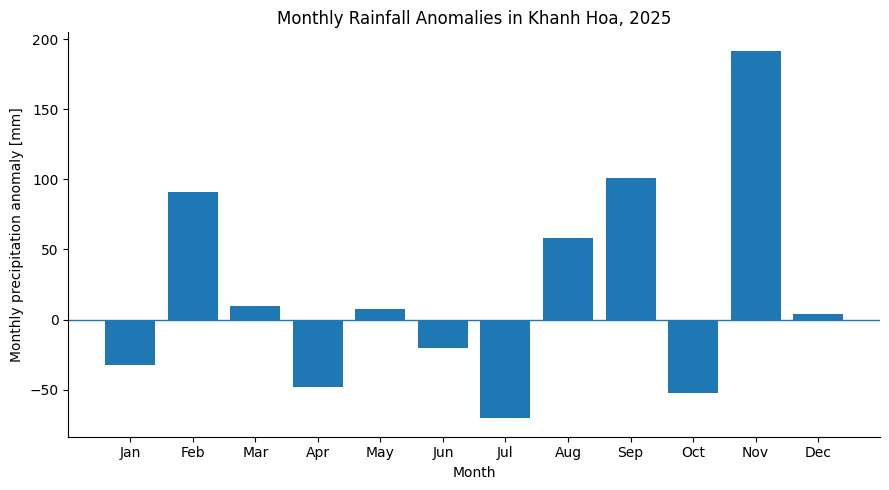

In [113]:
# Monthly rainfall anomalies in Khanh Hoa during 2025

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    khanh_hoa_2025_summary["Month"].str[:3],
    khanh_hoa_2025_summary["Anomaly [mm]"]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel("Month")
ax.set_ylabel("Monthly precipitation anomaly [mm]")

ax.set_title(
    "Monthly Rainfall Anomalies in Khanh Hoa, 2025"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 12c: Historical context and distribution of November 2025 rainfall

November 2025 rainfall is compared with historical November rainfall in Khanh Hoa from 1950 to 2024.

Its rarity is assessed using the historical percentile, rank, and empirical return period, while the historical distribution shows where November 2025 lies relative to previous November conditions.

In [114]:
# Extract historical November rainfall in Khanh Hoa

historical_november = (
    khanh_hoa_monthly
    .sel(valid_time=slice("1950-01-01", "2024-12-31"))
    .where(
        khanh_hoa_monthly
        .sel(valid_time=slice("1950-01-01", "2024-12-31"))
        ["valid_time"].dt.month == 11,
        drop=True
    )
    .to_series()
    .dropna()
)

# November 2025 rainfall
november_2025 = float(
    khanh_hoa_monthly.sel(
        valid_time="2025-11-01"
    )
)

# Historical November mean
historical_november_mean = (
    historical_november.mean()
)

# Historical percentile
november_percentile = (
    stats.percentileofscore(
        historical_november.values,
        november_2025,
        kind="rank"
    )
)

# Add November 2025 to the historical sample
all_novembers = pd.concat([
    historical_november,
    pd.Series(
        [november_2025],
        index=[pd.Timestamp("2025-11-01")]
    )
])

# Rank from wettest to driest
november_rank_wettest = (
    all_novembers.rank(
        ascending=False,
        method="min"
    ).loc[pd.Timestamp("2025-11-01")]
)

# Empirical return period
n_november = len(all_novembers)

november_return_period = (
    (n_november + 1)
    / november_rank_wettest
)

print(
    f"November 2025 rainfall: "
    f"{november_2025:.1f} mm"
)

print(
    f"Historical November mean: "
    f"{historical_november_mean:.1f} mm"
)

print(
    f"Historical percentile: "
    f"{november_percentile:.1f}th percentile"
)

print(
    f"Rank among 1950–2025 Novembers: "
    f"{int(november_rank_wettest)} of {n_november}"
)

print(
    f"Historical November maximum before 2025: "
    f"{historical_november.max():.1f} mm"
)

print(
    f"Empirical return period: "
    f"{november_return_period:.1f} years"
)

November 2025 rainfall: 475.2 mm
Historical November mean: 283.5 mm
Historical percentile: 89.3th percentile
Rank among 1950–2025 Novembers: 9 of 76
Historical November maximum before 2025: 726.2 mm
Empirical return period: 8.6 years


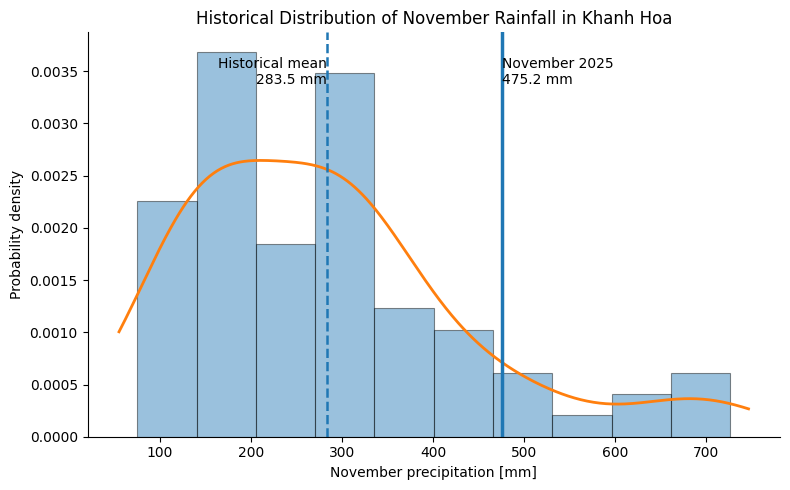

In [115]:
# Historical distribution of November rainfall in Khanh Hoa

historical_november_values = (
    historical_november.values
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    historical_november_values,
    bins=10,
    density=True,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.8
)

kde = stats.gaussian_kde(
    historical_november_values
)

x_grid = np.linspace(
    historical_november_values.min() - 20,
    historical_november_values.max() + 20,
    500
)

ax.plot(
    x_grid,
    kde(x_grid),
    linewidth=2
)

ax.axvline(
    historical_november_mean,
    linestyle="--",
    linewidth=1.8
)

ax.axvline(
    november_2025,
    linewidth=2.5
)

ymax = ax.get_ylim()[1]

ax.text(
    historical_november_mean,
    ymax * 0.94,
    f"Historical mean\n"
    f"{historical_november_mean:.1f} mm",
    ha="right",
    va="top"
)

ax.text(
    november_2025,
    ymax * 0.94,
    f"November 2025\n"
    f"{november_2025:.1f} mm",
    ha="left",
    va="top"
)

ax.set_xlabel("November precipitation [mm]")
ax.set_ylabel("Probability density")

ax.set_title(
    "Historical Distribution of November Rainfall in Khanh Hoa"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 12d: ENSO conditions preceding November 2025

Historical ENSO–rainfall relationships in Khanh Hoa are compared with the actual Niño 3.4 conditions at 0-, 1-, 3-, and 6-month leads before November 2025.

This comparison assesses whether the wetter-than-normal conditions observed in November 2025 were consistent with the historical ENSO signal.

In [116]:
# Historical monthly rainfall climatology: 1950–2024

kh_hist = khanh_hoa_monthly.sel(
    valid_time=slice("1950-01-01", "2024-12-31")
)

kh_monthly_climatology = (
    kh_hist
    .groupby("valid_time.month")
    .mean("valid_time")
)

# Remove the seasonal rainfall cycle
kh_rainfall_anomaly = (
    kh_hist.groupby("valid_time.month")
    - kh_monthly_climatology
)

# Convert rainfall and ENSO to pandas Series
rainfall_hist_kh = (
    kh_rainfall_anomaly
    .to_series()
    .dropna()
)

enso_hist_kh = (
    Enso_34
    .sel(time=slice("1950-01-01", "2024-12-31"))
    .to_series()
    .dropna()
)

# Align both datasets by calendar month
rainfall_hist_kh.index = (
    rainfall_hist_kh.index.to_period("M")
)

enso_hist_kh.index = (
    enso_hist_kh.index.to_period("M")
)

# Test whether ENSO leads rainfall by 0, 1, 3, or 6 months
lags = [0, 1, 3, 6]

kh_correlation_results = []

for lag in lags:

    # Positive lag means ENSO leads rainfall
    enso_lagged = enso_hist_kh.shift(lag)

    aligned = pd.concat(
        [rainfall_hist_kh, enso_lagged],
        axis=1
    ).dropna()

    r, p = stats.pearsonr(
        aligned.iloc[:, 0],
        aligned.iloc[:, 1]
    )

    kh_correlation_results.append({
        "ENSO lead (months)": lag,
        "Pearson r": r,
        "p-value": p,
        "r² (%)": (r ** 2) * 100
    })

kh_enso_correlation = pd.DataFrame(
    kh_correlation_results
)

# ENSO conditions corresponding to November 2025
reference_dates = {
    0: "2025-11-01",
    1: "2025-10-01",
    3: "2025-08-01",
    6: "2025-05-01"
}

reference_months = {
    0: "November 2025",
    1: "October 2025",
    3: "August 2025",
    6: "May 2025"
}

comparison_results = []

for _, row in kh_enso_correlation.iterrows():

    lag = int(row["ENSO lead (months)"])
    r = float(row["Pearson r"])
    p = float(row["p-value"])

    enso_value = float(
        Enso_34.sel(
            time=reference_dates[lag]
        )
    )

    # Rule-based interpretation
    if abs(enso_value) < 0.1:
        interpretation = "Neutral ENSO"

    elif p >= 0.05:
        interpretation = "Historical relationship not significant"

    elif r < 0 and enso_value < 0:
        interpretation = "Direction consistent with wetter conditions"

    elif r < 0 and enso_value > 0:
        interpretation = "Direction inconsistent with wetter conditions"

    elif r > 0 and enso_value > 0:
        interpretation = "Direction consistent with wetter conditions"

    else:
        interpretation = "Direction inconsistent with wetter conditions"

    comparison_results.append({
        "ENSO lead":
            f"{lag} month"
            if lag == 1
            else f"{lag} months",
        "Reference month":
            reference_months[lag],
        "Pearson r": r,
        "p-value": p,
        "r² (%)": (r ** 2) * 100,
        "Niño 3.4": enso_value,
        "Interpretation": interpretation
    })

kh_november_enso_comparison = pd.DataFrame(
    comparison_results
)

# Format for display
kh_november_enso_display = (
    kh_november_enso_comparison.copy()
)

kh_november_enso_display["Pearson r"] = (
    kh_november_enso_display["Pearson r"]
    .map(lambda x: f"{x:.3f}")
)

kh_november_enso_display["p-value"] = (
    kh_november_enso_display["p-value"]
    .map(
        lambda x: "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

kh_november_enso_display["r² (%)"] = (
    kh_november_enso_display["r² (%)"]
    .map(lambda x: f"{x:.1f}")
)

kh_november_enso_display["Niño 3.4"] = (
    kh_november_enso_display["Niño 3.4"]
    .map(lambda x: f"{x:+.2f}")
)

kh_november_enso_display

,ENSO lead,Reference month,Pearson r,p-value,r² (%),Niño 3.4,Interpretation
0,0 months,November 2025,-0.236,<0.001,5.6,-0.26,Direction consistent with wetter conditions
1,1 month,October 2025,-0.198,<0.001,3.9,+0.01,Neutral ENSO
2,3 months,August 2025,-0.168,<0.001,2.8,+0.09,Neutral ENSO
3,6 months,May 2025,-0.050,0.138,0.2,+0.31,Historical relationship not significant


## 13: Ho Chi Minh City case study — rainfall conditions in 2026

The analysis now turns to Ho Chi Minh City to examine rainfall conditions during 2026.

Because the ERA5-Land dataset currently extends through August 2026, the analysis covers January to August. Monthly rainfall is compared with the corresponding historical monthly climatology to identify unusually wet conditions before examining the wettest positive anomaly in greater detail.

### 13a: Monthly precipitation in Ho Chi Minh City during 2026

Ho Chi Minh City is examined separately to assess rainfall conditions from January to August 2026.

The administrative boundary is extracted from Natural Earth and used to calculate an area-weighted monthly precipitation series over the city.

In [117]:
# Extract Ho Chi Minh City boundary from Natural Earth admin-1 data

admin1_shp = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_1_states_provinces"
)

admin1_reader = shpreader.Reader(admin1_shp)

hcm_geometry = None

for record in admin1_reader.records():

    name = record.attributes.get("name")

    if name == "Hồ Chí Minh city":
        hcm_geometry = record.geometry
        break

if hcm_geometry is None:
    raise ValueError("Ho Chi Minh City was not found.")

# Create city mask on the ERA5-Land grid
lon2d, lat2d = np.meshgrid(
    precip.longitude.values,
    precip.latitude.values
)

hcm_mask = contains_xy(
    hcm_geometry,
    lon2d,
    lat2d
)

hcm_mask = xr.DataArray(
    hcm_mask,
    coords={
        "latitude": precip.latitude,
        "longitude": precip.longitude
    },
    dims=("latitude", "longitude")
)

print(
    "Ho Chi Minh City grid cells:",
    int(hcm_mask.sum())
)

Ho Chi Minh City grid cells: 17


In [118]:
# Calculate area-weighted monthly rainfall over Ho Chi Minh City

lat_weights_hcm = np.cos(
    np.deg2rad(precip["latitude"])
)

lat_weights_hcm = xr.DataArray(
    lat_weights_hcm,
    coords={"latitude": precip["latitude"]},
    dims=["latitude"]
)

hcm_monthly = (
    precip.where(hcm_mask)
    .weighted(lat_weights_hcm)
    .mean(dim=("latitude", "longitude"))
)

print(
    "Valid monthly observations:",
    int(hcm_monthly.notnull().sum())
)

Valid monthly observations: 920


### 13b: Rainfall anomalies in Ho Chi Minh City during 2026

Monthly rainfall from January to August 2026 is compared with the corresponding historical monthly climatology over 1950–2025.

Because each month is compared with the same calendar month in the historical record, the seasonal rainfall cycle is accounted for. Absolute and percentage anomalies are calculated to identify unusually wet months during 2026.

In [119]:
# Historical monthly climatology: 1950–2025

hcm_climatology = (
    hcm_monthly
    .sel(valid_time=slice("1950-01-01", "2025-12-31"))
    .groupby("valid_time.month")
    .mean(dim="valid_time")
)

# Monthly rainfall from January to August 2026
hcm_2026 = hcm_monthly.sel(
    valid_time=slice("2026-01-01", "2026-08-31")
)

results = []

for date, rainfall in zip(
    hcm_2026.valid_time.values,
    hcm_2026.values
):

    timestamp = pd.Timestamp(date)
    month = timestamp.month
    month_name = timestamp.strftime("%B")

    climatology = float(
        hcm_climatology.sel(month=month)
    )

    anomaly = float(rainfall) - climatology

    anomaly_percent = (
        anomaly / climatology
    ) * 100

    results.append({
        "Month": month_name,
        "Rainfall 2026 [mm]": float(rainfall),
        "Climatology 1950–2025 [mm]": climatology,
        "Anomaly [mm]": anomaly,
        "Anomaly [%]": anomaly_percent
    })

hcm_2026_summary = pd.DataFrame(results)

hcm_2026_summary = (
    hcm_2026_summary.round(1)
)

hcm_2026_summary

,Month,Rainfall 2026 [mm],Climatology 1950–2025 [mm],Anomaly [mm],Anomaly [%]
0,January,7.5,20.9,-13.4,-64.2
1,February,35.8,11.4,24.4,214.5
2,March,14.2,26.4,-12.2,-46.3
3,April,7.6,74.7,-67.1,-89.8
4,May,173.9,214.3,-40.5,-18.9
5,June,250.0,260.4,-10.3,-4.0
6,July,328.3,276.2,52.1,18.9
7,August,242.1,277.0,-35.0,-12.6


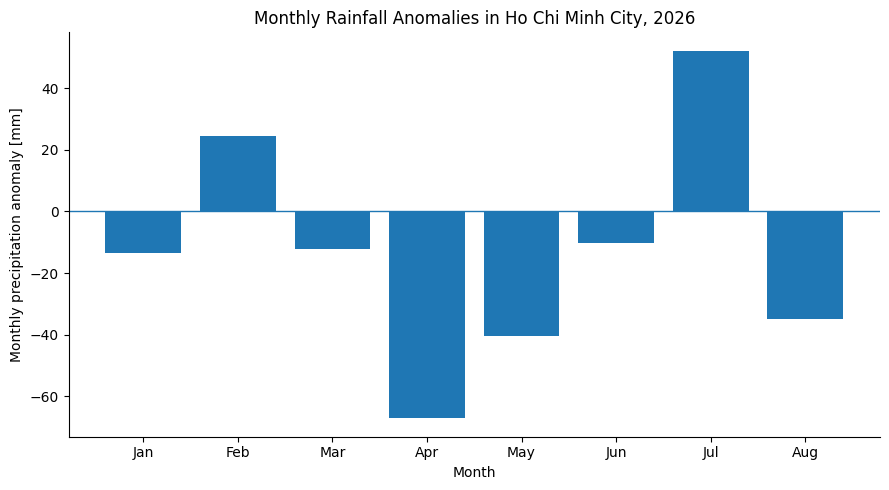

In [120]:
# Monthly rainfall anomalies in Ho Chi Minh City during 2026

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    hcm_2026_summary["Month"].str[:3],
    hcm_2026_summary["Anomaly [mm]"]
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel("Month")
ax.set_ylabel("Monthly precipitation anomaly [mm]")

ax.set_title(
    "Monthly Rainfall Anomalies in Ho Chi Minh City, 2026"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 13c: Historical context and distribution of July 2026 rainfall

July 2026 rainfall is compared with historical July rainfall in Ho Chi Minh City from 1950 to 2025.

Its rarity is assessed using the historical percentile, rank, and empirical return period, while the historical distribution shows where July 2026 lies relative to previous July conditions.

In [121]:
# Extract historical July rainfall in Ho Chi Minh City

historical_july = (
    hcm_monthly
    .sel(valid_time=slice("1950-01-01", "2025-12-31"))
    .where(
        hcm_monthly
        .sel(valid_time=slice("1950-01-01", "2025-12-31"))
        ["valid_time"].dt.month == 7,
        drop=True
    )
    .to_series()
    .dropna()
)

# July 2026 rainfall
july_2026 = float(
    hcm_monthly.sel(
        valid_time="2026-07-01"
    )
)

# Historical July mean
historical_july_mean = (
    historical_july.mean()
)

# Historical percentile
july_percentile = (
    stats.percentileofscore(
        historical_july.values,
        july_2026,
        kind="rank"
    )
)

# Add July 2026 to the historical sample
all_julys = pd.concat([
    historical_july,
    pd.Series(
        [july_2026],
        index=[pd.Timestamp("2026-07-01")]
    )
])

# Rank from wettest to driest
july_rank_wettest = (
    all_julys.rank(
        ascending=False,
        method="min"
    ).loc[pd.Timestamp("2026-07-01")]
)

# Empirical return period
n_july = len(all_julys)

july_return_period = (
    (n_july + 1)
    / july_rank_wettest
)

print(
    f"July 2026 rainfall: "
    f"{july_2026:.1f} mm"
)

print(
    f"Historical July mean: "
    f"{historical_july_mean:.1f} mm"
)

print(
    f"Historical percentile: "
    f"{july_percentile:.1f}th percentile"
)

print(
    f"Rank among 1950–2026 Julys: "
    f"{int(july_rank_wettest)} of {n_july}"
)

print(
    f"Historical July maximum before 2026: "
    f"{historical_july.max():.1f} mm"
)

print(
    f"Empirical return period: "
    f"{july_return_period:.1f} years"
)

July 2026 rainfall: 328.3 mm
Historical July mean: 276.2 mm
Historical percentile: 84.2th percentile
Rank among 1950–2026 Julys: 13 of 77
Historical July maximum before 2026: 454.2 mm
Empirical return period: 6.0 years


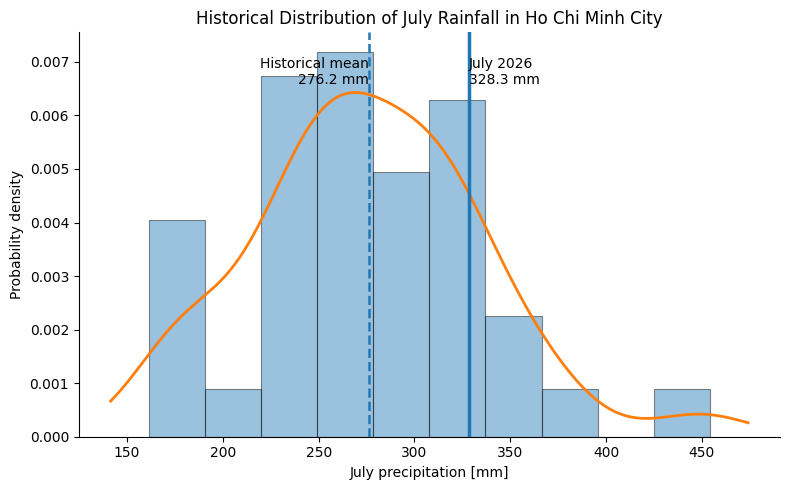

In [122]:
# Historical distribution of July rainfall in Ho Chi Minh City

historical_july_values = (
    historical_july.values
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    historical_july_values,
    bins=10,
    density=True,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.8
)

kde = stats.gaussian_kde(
    historical_july_values
)

x_grid = np.linspace(
    historical_july_values.min() - 20,
    historical_july_values.max() + 20,
    500
)

ax.plot(
    x_grid,
    kde(x_grid),
    linewidth=2
)

ax.axvline(
    historical_july_mean,
    linestyle="--",
    linewidth=1.8
)

ax.axvline(
    july_2026,
    linewidth=2.5
)

ymax = ax.get_ylim()[1]

ax.text(
    historical_july_mean,
    ymax * 0.94,
    f"Historical mean\n"
    f"{historical_july_mean:.1f} mm",
    ha="right",
    va="top"
)

ax.text(
    july_2026,
    ymax * 0.94,
    f"July 2026\n"
    f"{july_2026:.1f} mm",
    ha="left",
    va="top"
)

ax.set_xlabel("July precipitation [mm]")
ax.set_ylabel("Probability density")

ax.set_title(
    "Historical Distribution of July Rainfall in Ho Chi Minh City"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### 13d: ENSO conditions preceding July 2026

Historical ENSO–rainfall relationships in Ho Chi Minh City are compared with the actual Niño 3.4 conditions at 0-, 1-, 3-, and 6-month leads before July 2026.

This comparison assesses whether the wetter-than-normal conditions observed in July 2026 were consistent with the historical ENSO signal.

In [123]:
# Historical monthly rainfall climatology: 1950–2025

hcm_hist = hcm_monthly.sel(
    valid_time=slice("1950-01-01", "2025-12-31")
)

hcm_monthly_climatology = (
    hcm_hist
    .groupby("valid_time.month")
    .mean("valid_time")
)

# Remove the seasonal rainfall cycle
hcm_rainfall_anomaly = (
    hcm_hist.groupby("valid_time.month")
    - hcm_monthly_climatology
)

# Convert rainfall and ENSO to pandas Series
rainfall_hist_hcm = (
    hcm_rainfall_anomaly
    .to_series()
    .dropna()
)

enso_hist_hcm = (
    Enso_34
    .sel(time=slice("1950-01-01", "2025-12-31"))
    .to_series()
    .dropna()
)

# Align both datasets by calendar month
rainfall_hist_hcm.index = (
    rainfall_hist_hcm.index.to_period("M")
)

enso_hist_hcm.index = (
    enso_hist_hcm.index.to_period("M")
)

# Test whether ENSO leads rainfall by 0, 1, 3, or 6 months
lags = [0, 1, 3, 6]

hcm_correlation_results = []

for lag in lags:

    # Positive lag means ENSO leads rainfall
    enso_lagged = enso_hist_hcm.shift(lag)

    aligned = pd.concat(
        [rainfall_hist_hcm, enso_lagged],
        axis=1
    ).dropna()

    r, p = stats.pearsonr(
        aligned.iloc[:, 0],
        aligned.iloc[:, 1]
    )

    hcm_correlation_results.append({
        "ENSO lead (months)": lag,
        "Pearson r": r,
        "p-value": p,
        "r² (%)": (r ** 2) * 100
    })

hcm_enso_correlation = pd.DataFrame(
    hcm_correlation_results
)

# ENSO conditions corresponding to July 2026
reference_dates = {
    0: "2026-07-01",
    1: "2026-06-01",
    3: "2026-04-01",
    6: "2026-01-01"
}

reference_months = {
    0: "July 2026",
    1: "June 2026",
    3: "April 2026",
    6: "January 2026"
}

comparison_results = []

for _, row in hcm_enso_correlation.iterrows():

    lag = int(row["ENSO lead (months)"])
    r = float(row["Pearson r"])
    p = float(row["p-value"])

    enso_value = float(
        Enso_34.sel(
            time=reference_dates[lag]
        )
    )

    # Rule-based interpretation
    if abs(enso_value) < 0.1:
        interpretation = "Neutral ENSO"

    elif p >= 0.05:
        interpretation = "Historical relationship not significant"

    elif r < 0 and enso_value < 0:
        interpretation = "Direction consistent with wetter conditions"

    elif r < 0 and enso_value > 0:
        interpretation = "Direction inconsistent with wetter conditions"

    elif r > 0 and enso_value > 0:
        interpretation = "Direction consistent with wetter conditions"

    else:
        interpretation = "Direction inconsistent with wetter conditions"

    comparison_results.append({
        "ENSO lead":
            f"{lag} month"
            if lag == 1
            else f"{lag} months",
        "Reference month":
            reference_months[lag],
        "Pearson r": r,
        "p-value": p,
        "r² (%)": (r ** 2) * 100,
        "Niño 3.4": enso_value,
        "Interpretation": interpretation
    })

hcm_july_enso_comparison = pd.DataFrame(
    comparison_results
)

# Format for display
hcm_july_enso_display = (
    hcm_july_enso_comparison.copy()
)

hcm_july_enso_display["Pearson r"] = (
    hcm_july_enso_display["Pearson r"]
    .map(lambda x: f"{x:.3f}")
)

hcm_july_enso_display["p-value"] = (
    hcm_july_enso_display["p-value"]
    .map(
        lambda x: "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

hcm_july_enso_display["r² (%)"] = (
    hcm_july_enso_display["r² (%)"]
    .map(lambda x: f"{x:.1f}")
)

hcm_july_enso_display["Niño 3.4"] = (
    hcm_july_enso_display["Niño 3.4"]
    .map(lambda x: f"{x:+.2f}")
)

hcm_july_enso_display

,ENSO lead,Reference month,Pearson r,p-value,r² (%),Niño 3.4,Interpretation
0,0 months,July 2026,-0.192,<0.001,3.7,+2.73,Direction inconsistent with wetter conditions
1,1 month,June 2026,-0.164,<0.001,2.7,+2.23,Direction inconsistent with wetter conditions
2,3 months,April 2026,-0.174,<0.001,3.0,+0.85,Direction inconsistent with wetter conditions
3,6 months,January 2026,-0.069,0.038,0.5,-0.29,Direction consistent with wetter conditions
